# Anticipation from Regression Residual — CISI (BLA-template removal)

**Goal:** Isolate anticipation-related neural activity in the **P1** protocol (auditory cue → tactile target @ 500 ms) by regressing out each subject's **auditory-only (BLA)** ERP from the cue–target window, and track its **trial-by-trial** dynamics.

**Pipeline:**
1. Load **BLA** (auditory-only), **BLT** (tactile-only), and **P1** (cue→tactile @ 500 ms) for each subject (same channel list). **BLT** is used for sanity overlays vs P1; the regression template remains **BLA** only.
2. Baseline-correct both in **−500…−50 ms**.
3. Per subject × channel: build BLA grand-average **template**.
4. For each P1 trial × channel: fit **β by OLS on 0–200 ms** (auditory-dominated) and define **residual = P1 − β · template** over the full epoch.
5. Extract anticipation features from the **residual** on **C+CP**: mean amplitude 200–500 ms + **CNV slope** 200–500 ms. Use **T+TP** as negative control.
6. Parallel frequency-domain indicator on **raw P1**: α (8–13 Hz) and β (13–30 Hz) **ERD** on C+CP over 200–500 ms (Welch, dB vs baseline).
7. Trial-by-trial rolling means + first-10 vs last-10 paired t / Wilcoxon.
8. Sanity checks: N1/P2 comparability (BLA vs P1) and topography of the residual.

**Why this is more defensible than a raw `f_ant`:**
- **Topographic:** features are measured on C+CP; T+TP is the explicit negative control.
- **Subtractive:** fitting β in the auditory-dominated 0–200 ms window and looking at 200–500 ms residual forces the feature to be *whatever is not explained by a scaled auditory ERP*.
- **Frequency-orthogonal:** mu/β ERD on C+CP is in a frequency regime different from phase-locked auditory P3.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import hilbert, butter, filtfilt
import warnings, contextlib, io

from utils import load_eeg_data, CHANNEL_GROUPS

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


In [2]:
# --- Parameters ---
CUE_CONDITION           = "P1"    # auditory cue → tactile target @ 500 ms
AUDITORY_ONLY_CONDITION = "BLA"   # auditory-only control
TACTILE_ONLY_CONDITION  = "BLT"   # tactile-only control (no auditory-cued anticipation)

# 14 channels: original CISI ROI (T/TP/C/CP) + frontocentral cluster (CNV core) + F3 (left dlPFC)
CHANNELS_LIST = [
    "T7", "T8", "TP7", "TP8",                 # auditory ROI (neg. control)
    "C3", "C4", "CP1", "CP2",                 # central ROI (somato-anticipation)
    "FZ", "FC1", "FC2", "Cz", "CPZ",        # frontocentral cluster (CNV core: SMA/ACC)
    "F3",                                         # left dlPFC — attention/WM in anticipation
]

ROI_AUDITORY = ["T7", "T8", "TP7", "TP8"]                 # T+TP — negative control
ROI_CENTRAL  = ["C3", "C4", "CP1", "CP2"]                 # C+CP — somato-anticipation
ROI_FC_MID   = ["FZ", "FC1", "FC2", "Cz", "CPZ"]        # FCmid — CNV core
ROI_F3       = ["F3"]                                         # F3   — left dlPFC (standalone)
REGIONS      = {
    "T":   ["T7", "T8"],
    "TP":  ["TP7", "TP8"],
    "C":   ["C3", "C4"],
    "CP":  ["CP1", "CP2"],
    "FZ":  ["FZ"],
    "FC1": ["FC1"],
    "FC2": ["FC2"],
    "Cz":  ["Cz"],
    "CPZ": ["CPZ"],
    "F3":  ["F3"],
}

SUBJECT_IDS = [s for s in range(1, 18) if s not in (1, 4, 14)]

FREQ_BAND_TD = "delta_beta"              # 1–30 Hz for time-domain
BASELINE_TMIN, BASELINE_TMAX = -0.500, -0.050
AUD_FIT_TMIN,  AUD_FIT_TMAX  =  0.000,  0.200  # β fit (auditory-dominated)
ANT_TMIN,      ANT_TMAX      =  0.200,  0.500  # anticipation window (residual)

BANDS_ERD      = {"alpha": (8.0, 13.0), "beta": (13.0, 30.0)}
ROLLING_WINDOW = 5

print(f"Subjects            : {SUBJECT_IDS}")
print(f"Cue condition       : {CUE_CONDITION}  (auditory → tactile @ 500 ms)")
print(f"Auditory-only ctrl  : {AUDITORY_ONLY_CONDITION}")
print(f"Tactile-only ctrl   : {TACTILE_ONLY_CONDITION}")
print(f"Channels            : {CHANNELS_LIST}")
print(f"  T+TP  (neg ctrl)   : {ROI_AUDITORY}")
print(f"  C+CP  (somato)     : {ROI_CENTRAL}")
print(f"  FCmid (CNV core)   : {ROI_FC_MID}")
print(f"  F3    (L dlPFC)    : {ROI_F3}")
print(f"β fit window        : {AUD_FIT_TMIN*1000:.0f}–{AUD_FIT_TMAX*1000:.0f} ms")
print(f"Anticipation window : {ANT_TMIN*1000:.0f}–{ANT_TMAX*1000:.0f} ms")


Subjects            : [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Cue condition       : P1  (auditory → tactile @ 500 ms)
Auditory-only ctrl  : BLA
Tactile-only ctrl   : BLT
Channels            : ['T7', 'T8', 'TP7', 'TP8', 'C3', 'C4', 'CP1', 'CP2', 'FZ', 'FC1', 'FC2', 'Cz', 'CPZ', 'F3']
  T+TP  (neg ctrl)   : ['T7', 'T8', 'TP7', 'TP8']
  C+CP  (somato)     : ['C3', 'C4', 'CP1', 'CP2']
  FCmid (CNV core)   : ['FZ', 'FC1', 'FC2', 'Cz', 'CPZ']
  F3    (L dlPFC)    : ['F3']
β fit window        : 0–200 ms
Anticipation window : 200–500 ms


## 1. Load BLA, BLT, and P1 (baseline-corrected)

In [3]:
def _load_bc(condition, subject_id, wanted_channels, freq_band, baseline):
    """Load epochs with 'all' channels, drop to wanted, baseline-subtract per trial × channel.

    Channels missing from the subject's montage are silently dropped;
    the caller can inspect the returned `missing` list."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            epochs = load_eeg_data(condition, subject_id, channels='all', freq_band=freq_band)
    present = [c for c in wanted_channels if c in epochs.ch_names]
    missing = [c for c in wanted_channels if c not in epochs.ch_names]
    epochs = epochs.copy().pick_channels(present, ordered=True)
    data = epochs.get_data() * 1e6
    times = epochs.times
    m = (times >= baseline[0]) & (times <= baseline[1])
    if not m.any():
        raise ValueError(f"Baseline {baseline} not in epoch times.")
    data = data - data[:, :, m].mean(axis=-1, keepdims=True)
    return epochs, data, times, missing


sub_pack, failed = {}, []

for sub_id in SUBJECT_IDS:
    try:
        ep_p1,  d_p1,  t_p1,  miss_p1  = _load_bc(CUE_CONDITION,          sub_id, CHANNELS_LIST, FREQ_BAND_TD, (BASELINE_TMIN, BASELINE_TMAX))
        ep_bla, d_bla, t_bla, miss_bla = _load_bc(AUDITORY_ONLY_CONDITION, sub_id, CHANNELS_LIST, FREQ_BAND_TD, (BASELINE_TMIN, BASELINE_TMAX))
        ep_blt, d_blt, t_blt, miss_blt = _load_bc(TACTILE_ONLY_CONDITION,  sub_id, CHANNELS_LIST, FREQ_BAND_TD, (BASELINE_TMIN, BASELINE_TMAX))
    except Exception as e:
        failed.append((sub_id, str(e)))
        continue

    if not (np.allclose(t_p1, t_bla) and np.allclose(t_p1, t_blt)):
        failed.append((sub_id, "BLA/BLT/P1 time axes differ"))
        continue
    if not (ep_p1.ch_names == ep_bla.ch_names == ep_blt.ch_names):
        failed.append((sub_id, "BLA/BLT/P1 channel order differ"))
        continue

    missing = sorted(set(miss_p1) | set(miss_bla) | set(miss_blt))

    sub_pack[sub_id] = {
        "p1_data":  d_p1,
        "bla_data": d_bla,
        "blt_data": d_blt,
        "times":    t_p1,
        "ch_names": ep_p1.ch_names,
        "sfreq":    float(ep_p1.info["sfreq"]),
        "missing":  missing,
    }
    tag = f" (missing: {missing})" if missing else ""
    print(f"sub {sub_id:>2}: P1 {d_p1.shape} | BLA {d_bla.shape} | BLT {d_blt.shape}{tag}")

if failed:
    print("\nSkipped:")
    for s, msg in failed:
        print(f"  sub {s}: {msg}")

loaded = sorted(sub_pack.keys())
print(f"\nLoaded {len(loaded)} subjects: {loaded}")


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub  2: P1 (60, 14, 1792) | BLA (60, 14, 1792) | BLT (60, 14, 1792)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub  3: P1 (60, 14, 1792) | BLA (60, 14, 1792) | BLT (60, 14, 1792)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
sub  5: P1 (60, 14, 1792) | BLA (60, 14, 1792) | BLT (60, 14, 1792)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(..

## 2. BLA template per subject × channel + sanity overlay

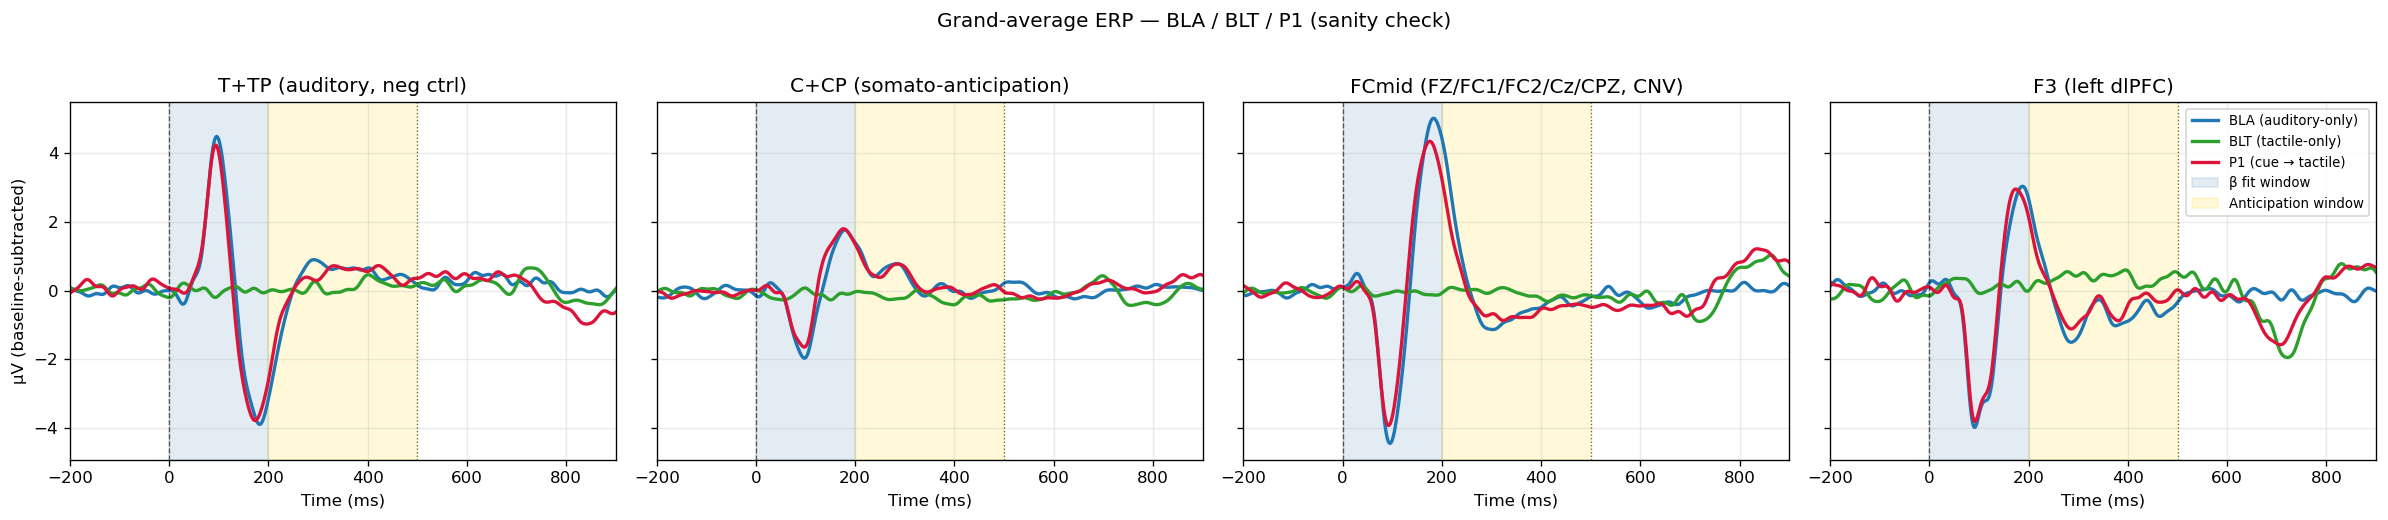

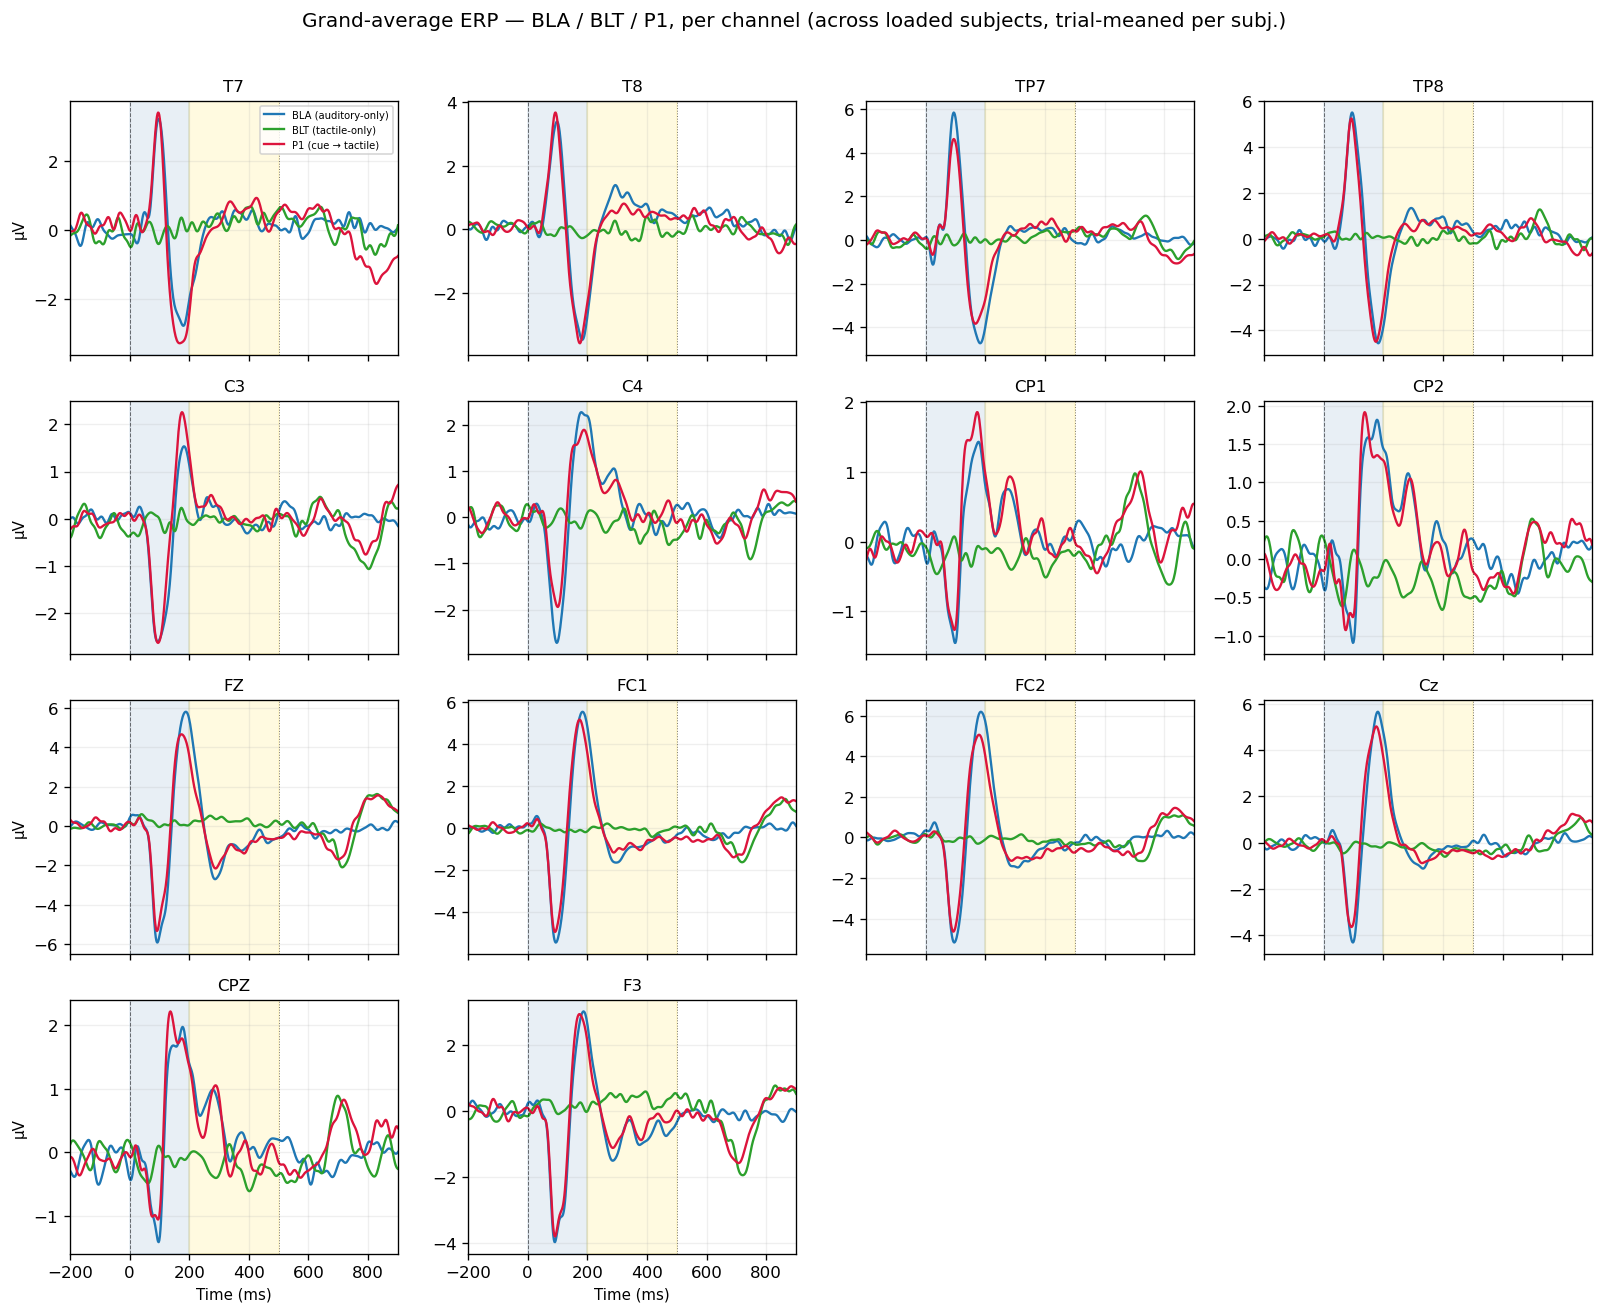

In [4]:
# Per-subject × channel BLA template (trial mean)
templates = {s: sub_pack[s]["bla_data"].mean(axis=0) for s in loaded}  # (n_ch, n_t)

ref = sub_pack[loaded[0]]
ch_names = ref["ch_names"]
times = ref["times"]
time_ms = times * 1000.0


def _across_subject_trial_mean(key):
    return np.stack([sub_pack[s][key].mean(axis=0) for s in loaded]).mean(axis=0)


def _roi_mean(grand_by_ch, roi):
    ix = [ch_names.index(c) for c in roi if c in ch_names]
    return grand_by_ch[ix].mean(axis=0)


ga_p1  = _across_subject_trial_mean("p1_data")
ga_bla = _across_subject_trial_mean("bla_data")
ga_blt = _across_subject_trial_mean("blt_data")

fig, axes = plt.subplots(1, 4, figsize=(20, 4.2), sharey=True)
for ax, (lab, roi) in zip(
    axes,
    [
        ("T+TP (auditory, neg ctrl)",       ROI_AUDITORY),
        ("C+CP (somato-anticipation)",      ROI_CENTRAL),
        ("FCmid (FZ/FC1/FC2/Cz/CPZ, CNV)",  ROI_FC_MID),
        ("F3 (left dlPFC)",                  ROI_F3),
    ],
):
    ax.plot(time_ms, _roi_mean(ga_bla, roi), color="#1f77b4", lw=2.0, label="BLA (auditory-only)")
    ax.plot(time_ms, _roi_mean(ga_blt, roi), color="#2ca02c", lw=2.0, label="BLT (tactile-only)")
    ax.plot(time_ms, _roi_mean(ga_p1,  roi), color="crimson", lw=2.0, label="P1 (cue → tactile)")
    ax.axvline(0,   color="k", ls="--", lw=0.8, alpha=0.6)
    ax.axvline(500, color="k", ls=":",  lw=0.8, alpha=0.6)
    ax.axvspan(AUD_FIT_TMIN*1000, AUD_FIT_TMAX*1000, alpha=0.15, color="steelblue", label="β fit window")
    ax.axvspan(ANT_TMIN*1000,     ANT_TMAX*1000,     alpha=0.15, color="gold",       label="Anticipation window")
    ax.set_xlim(-200, 900)
    ax.set_xlabel("Time (ms)")
    ax.set_title(lab)
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel("µV (baseline-subtracted)")
axes[-1].legend(loc="upper right", fontsize=8)
fig.suptitle("Grand-average ERP — BLA / BLT / P1 (sanity check)", y=1.02)
fig.tight_layout()
plt.show()

# Per-channel: same grand averages — BLA vs P1 on every electrode
n_ch = len(ch_names)
ncols = 4
nrows = int(np.ceil(n_ch / ncols))
fig2, axs2 = plt.subplots(
    nrows, ncols, figsize=(3.4 * ncols, 2.7 * nrows), sharex=True, sharey=False
)
axs2 = np.atleast_2d(axs2).ravel()
for i, ch in enumerate(ch_names):
    ax = axs2[i]
    ax.plot(time_ms, ga_bla[i], color="#1f77b4", lw=1.4, label="BLA (auditory-only)")
    ax.plot(time_ms, ga_blt[i], color="#2ca02c", lw=1.4, label="BLT (tactile-only)")
    ax.plot(time_ms, ga_p1[i], color="crimson", lw=1.4, label="P1 (cue → tactile)")
    ax.axvline(0, color="k", ls="--", lw=0.6, alpha=0.5)
    ax.axvline(500, color="k", ls=":", lw=0.6, alpha=0.5)
    ax.axvspan(AUD_FIT_TMIN * 1000, AUD_FIT_TMAX * 1000, alpha=0.12, color="steelblue")
    ax.axvspan(ANT_TMIN * 1000, ANT_TMAX * 1000, alpha=0.12, color="gold")
    ax.set_xlim(-200, 900)
    ax.set_title(ch, fontsize=10)
    ax.grid(True, alpha=0.2)
    row, col = i // ncols, i % ncols
    if row == nrows - 1:
        ax.set_xlabel("Time (ms)", fontsize=9)
    if col == 0:
        ax.set_ylabel("µV", fontsize=9)
axs2[0].legend(loc="upper right", fontsize=6)
for j in range(n_ch, nrows * ncols):
    axs2[j].set_visible(False)
fig2.suptitle(
    "Grand-average ERP — BLA / BLT / P1, per channel (across loaded subjects, trial-meaned per subj.)",
    y=1.01,
)
fig2.tight_layout()
plt.show()


## 2b. Pointwise **BLA vs P1** (paired *t* + **FDR** per channel in **[-500, 500] ms**)

For each **channel** and every time sample in **−500 to 500 ms** only, a **one-sample t-test** on the across-subject **difference** (trial-meaned **P1 − trial-meaned BLA** per subject) tests whether the two conditions differ. **Benjamini–Hochberg FDR** (α=0.05) is applied **separately within each channel** over that time range only (not the full epoch).

**Caveat:** time samples are **autocorrelated**; this is **exploratory** and does not replace **cluster-based permutation** for rigorous inference.

Paired design: n=14 subjects, trial-meaned ERP. Time: [-500, 500] ms only; n_time=513. Per-channel FDR α=0.05. Green = within-channel FDR-sig.

Per channel — FDR-sig. time ranges (P1 vs BLA):
  T7    n_bin=0/ 513  —
  T8    n_bin=0/ 513  —
  TP7   n_bin=0/ 513  —
  TP8   n_bin=3/ 513  127–131 ms
  C3    n_bin=0/ 513  —
  C4    n_bin=0/ 513  —
  CP1   n_bin=0/ 513  —
  CP2   n_bin=0/ 513  —
  FZ    n_bin=22/ 513  107–137 ms · 203–213 ms
  FC1   n_bin=15/ 513  109–137 ms
  FC2   n_bin=17/ 513  125–135 ms · 197–217 ms
  Cz    n_bin=0/ 513  —
  CPZ   n_bin=0/ 513  —
  F3    n_bin=0/ 513  —


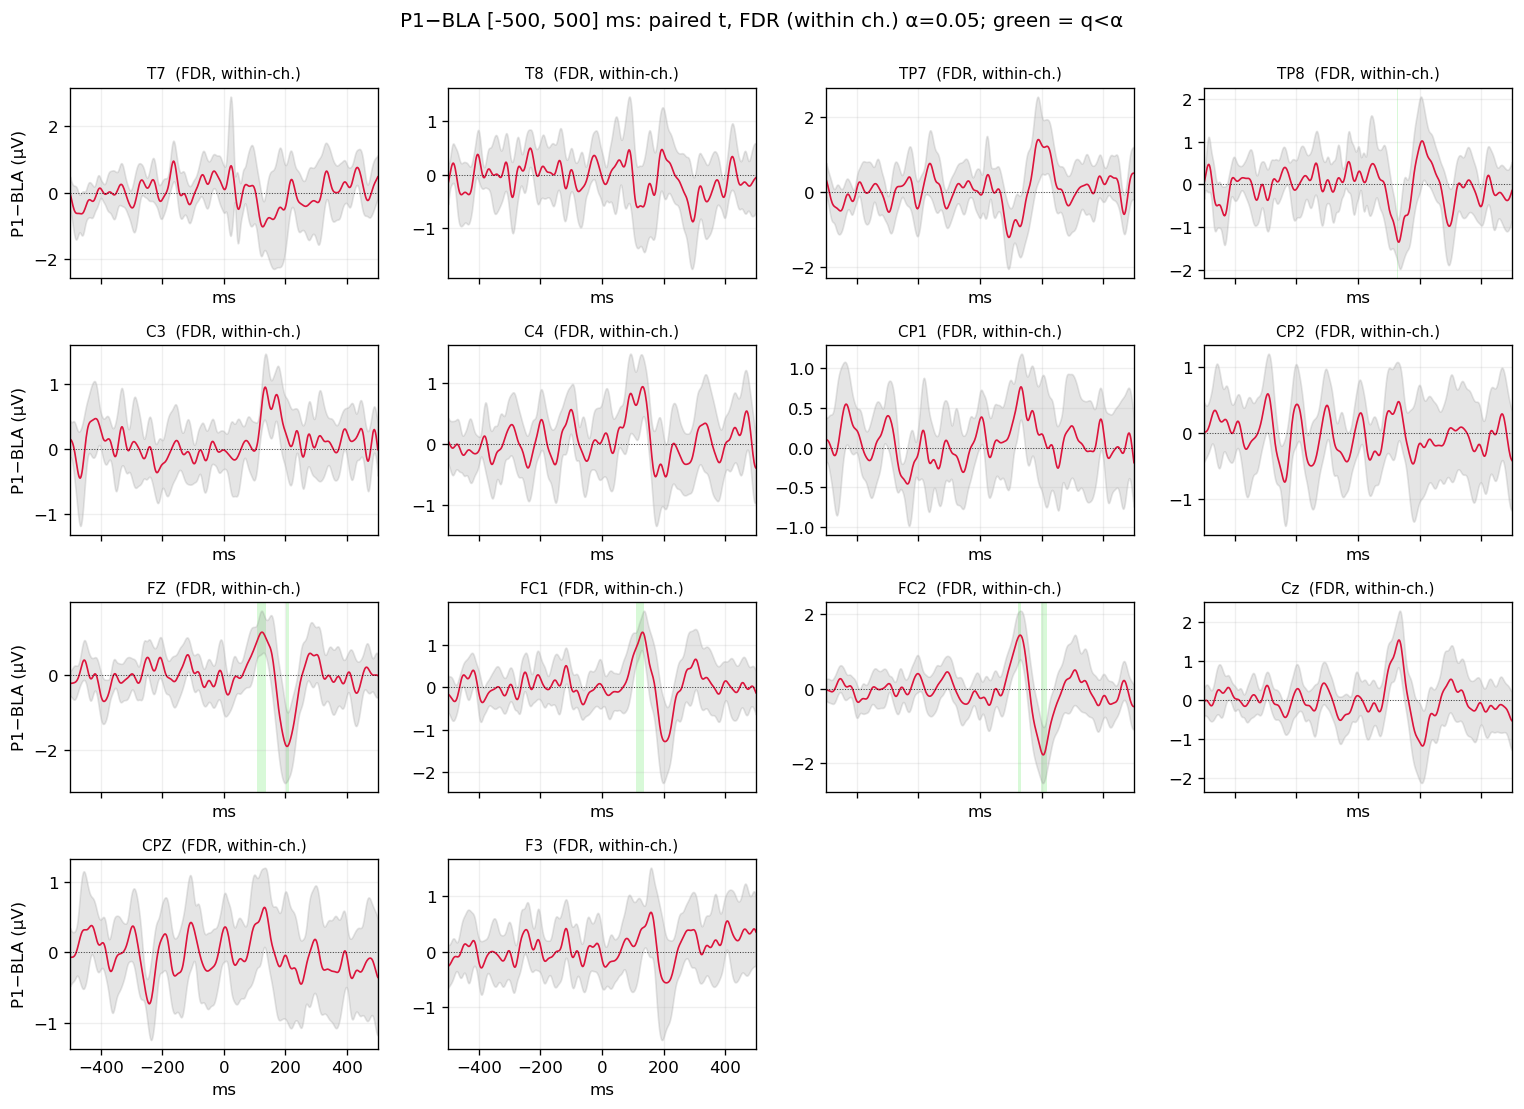

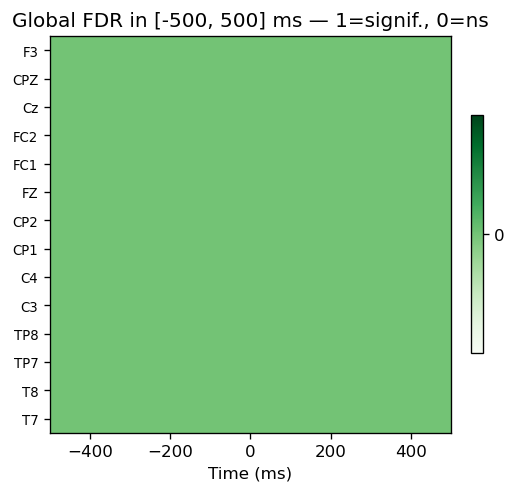

In [5]:
# --- P1 vs BLA, pointwise across subjects, FDR (BH) per channel over time ---

FDR_ALPHA = 0.05  # FDR on raw p's within each channel
# 统计、FDR 与作图只使用以下时间窗（本征单位：秒、毫秒）
FDR_TMIN_MS, FDR_TMAX_MS = -500.0, 500.0

if not loaded:
    print("No subjects in `loaded`; run §1 first.")
else:
    t_arr = sub_pack[loaded[0]]["times"]
    win = (t_arr * 1000.0 >= FDR_TMIN_MS) & (t_arr * 1000.0 <= FDR_TMAX_MS)
    if not np.any(win):
        raise ValueError(f"Empty window [{FDR_TMIN_MS}, {FDR_TMAX_MS}] ms on epoch time axis.")
    t_arr_w = t_arr[win]
    time_ms = t_arr_w * 1000.0
    Tw, nch = t_arr_w.size, len(ch_names)

    S_bla = np.stack([sub_pack[s]["bla_data"].mean(axis=0) for s in loaded], axis=0)  # (n_sub, n_ch, n_t)
    S_p1  = np.stack([sub_pack[s]["p1_data"].mean(axis=0)  for s in loaded], axis=0)
    D = S_p1 - S_bla
    D_w = D[:, :, win]
    n_sub = D_w.shape[0]

    def _fdr_bh(p, alpha=0.05):
        """FDR q-values, Benjamini–Hochberg; same length/order as p."""
        p = np.clip(np.asarray(p, dtype=float), 1e-20, 1.0)
        m = p.size
        if m < 1:
            return p.copy()
        o = np.argsort(p)
        ps = p[o]
        q = ps * m / (np.arange(1, m + 1))
        q = np.minimum.accumulate(q[::-1])[::-1]
        q = np.clip(q, 0, 1.0)
        out = np.empty_like(p)
        out[o] = q
        return out

    def _segments_ms(m_bool):
        """Contiguous *True* runs → [(start_ms, end_ms), ...] from mask aligned with time_ms."""
        m = np.asarray(m_bool, dtype=bool)
        if m.size == 0 or not np.any(m):
            return []
        d = np.diff(m.astype(int))
        starts = np.where(d == 1)[0] + 1
        if m[0]:
            starts = np.r_[0, starts]
        ends = np.where(d == -1)[0]
        if m[-1]:
            ends = np.r_[ends, m.size - 1]
        return [(time_ms[i], time_ms[j]) for i, j in zip(starts, ends)]

    p_raw = np.empty((nch, Tw))
    q_fdr = np.empty((nch, Tw))
    sig = np.empty((nch, Tw), dtype=bool)

    for c in range(nch):
        _, p_raw[c, :] = stats.ttest_1samp(D_w[:, c, :], 0, axis=0, nan_policy="omit")
    # FDR 不对 NaN p 作推断 — 当方差为 0 时 p 为 NaN
    p_raw = np.where(np.isfinite(p_raw), p_raw, 1.0)
    for c in range(nch):
        q_fdr[c, :] = _fdr_bh(p_raw[c, :], FDR_ALPHA)
        sig[c, :] = q_fdr[c, :] < FDR_ALPHA

    # *Global* FDR: 全部（通道×时间）在窗口内 一个 BH 家族
    p_flat = p_raw.ravel()
    q_glob = _fdr_bh(p_flat, FDR_ALPHA).reshape(nch, Tw)
    sig_glob = q_glob < FDR_ALPHA

    print(
        f"Paired design: n={n_sub} subjects, trial-meaned ERP. "
        f"Time: [{FDR_TMIN_MS:.0f}, {FDR_TMAX_MS:.0f}] ms only; n_time={Tw}. "
        f"Per-channel FDR α={FDR_ALPHA}. Green = within-channel FDR-sig."
    )
    print("\nPer channel — FDR-sig. time ranges (P1 vs BLA):")
    for c, ch in enumerate(ch_names):
        segs = _segments_ms(sig[c])
        s = " · ".join(f"{a:.0f}–{b:.0f} ms" for a, b in segs) if segs else "—"
        print(f"  {ch:4s}  n_bin={int(sig[c].sum())}/{Tw:4d}  {s[:120]}{'...' if len(s) > 120 else ''}")

    # --- Per-channel subplots: mean diff (P1−BLA) ± 95% CI + FDR-sig. shading ---
    ncols = 4
    nrows = int(np.ceil(nch / ncols))
    fig, axs = plt.subplots(
        nrows, ncols, figsize=(3.2 * ncols, 2.3 * nrows), sharex=True, sharey=False
    )
    axs = np.atleast_2d(axs).ravel()
    for c, ch in enumerate(ch_names):
        ax = axs[c]
        m = D_w[:, c, :]
        m_mu = m.mean(axis=0)
        m_se = m.std(axis=0, ddof=1) / np.sqrt(n_sub) if n_sub > 1 else np.zeros(Tw)
        for t0, t1 in _segments_ms(sig[c]):
            ax.axvspan(t0, t1, color="lightgreen", alpha=0.35, lw=0, zorder=0)
        ax.fill_between(
            time_ms, m_mu - 1.96 * m_se, m_mu + 1.96 * m_se, color="0.5", alpha=0.2, zorder=1
        )
        ax.plot(time_ms, m_mu, color="crimson", lw=1.0, zorder=2)
        ax.axhline(0, color="k", ls=":", lw=0.6, alpha=0.7)
        ax.set_title(f"{ch}  (FDR, within-ch.)", fontsize=9)
        ax.set_xlabel("ms")
        if c % ncols == 0:
            ax.set_ylabel("P1−BLA (µV)")
        ax.set_xlim(FDR_TMIN_MS, FDR_TMAX_MS)
        ax.grid(True, alpha=0.2)
    for c in range(nch, nrows * ncols):
        axs[c].set_visible(False)
    fig.suptitle(
        f"P1−BLA [{FDR_TMIN_MS:.0f}, {FDR_TMAX_MS:.0f}] ms: paired t, FDR (within ch.) α={FDR_ALPHA}; green = q<α",
        y=1.0,
    )
    fig.tight_layout()
    plt.show()

    # Second: global FDR 仅在同一时间窗
    fig2, ax2 = plt.subplots(1, 1, figsize=(0.3 * nch, 4), constrained_layout=True)
    im = ax2.imshow(
        (q_glob < FDR_ALPHA).astype(float),
        aspect="auto",
        origin="lower",
        cmap="Greens",
        extent=[FDR_TMIN_MS, FDR_TMAX_MS, 0, nch],
    )
    ax2.set_yticks(np.arange(nch) + 0.5)
    ax2.set_yticklabels(ch_names, fontsize=8)
    ax2.set_xlabel("Time (ms)")
    ax2.set_xlim(FDR_TMIN_MS, FDR_TMAX_MS)
    ax2.set_title(f"Global FDR in [{FDR_TMIN_MS:.0f}, {FDR_TMAX_MS:.0f}] ms — 1=signif., 0=ns")
    cbar = fig2.colorbar(im, ax=ax2, shrink=0.6, ticks=[0, 1])
    plt.show()


## 2c. Trial-by-trial dynamics **inside each FDR-significant segment**

Use §2b's **per-channel FDR mask** `sig` (in **−500…500 ms**) to define each channel's **FDR-significant segment(s)**. Then for **every trial × subject**, compute the **P1 mean amplitude inside that segment** (and the matched **subject's BLA mean** for a condition-difference trace). Across subjects we plot the **trial-by-trial dynamics** (mean ± SEM, rolling mean), and run a **first-N vs last-N** paired test.

**What this asks:** *Where group-level ERP differs from pure auditory (BLA), does the P1 amplitude in that window drift across trials (learning / habituation / boredom)?*

4/14 channels have FDR-sig. segments; total 6 segments.


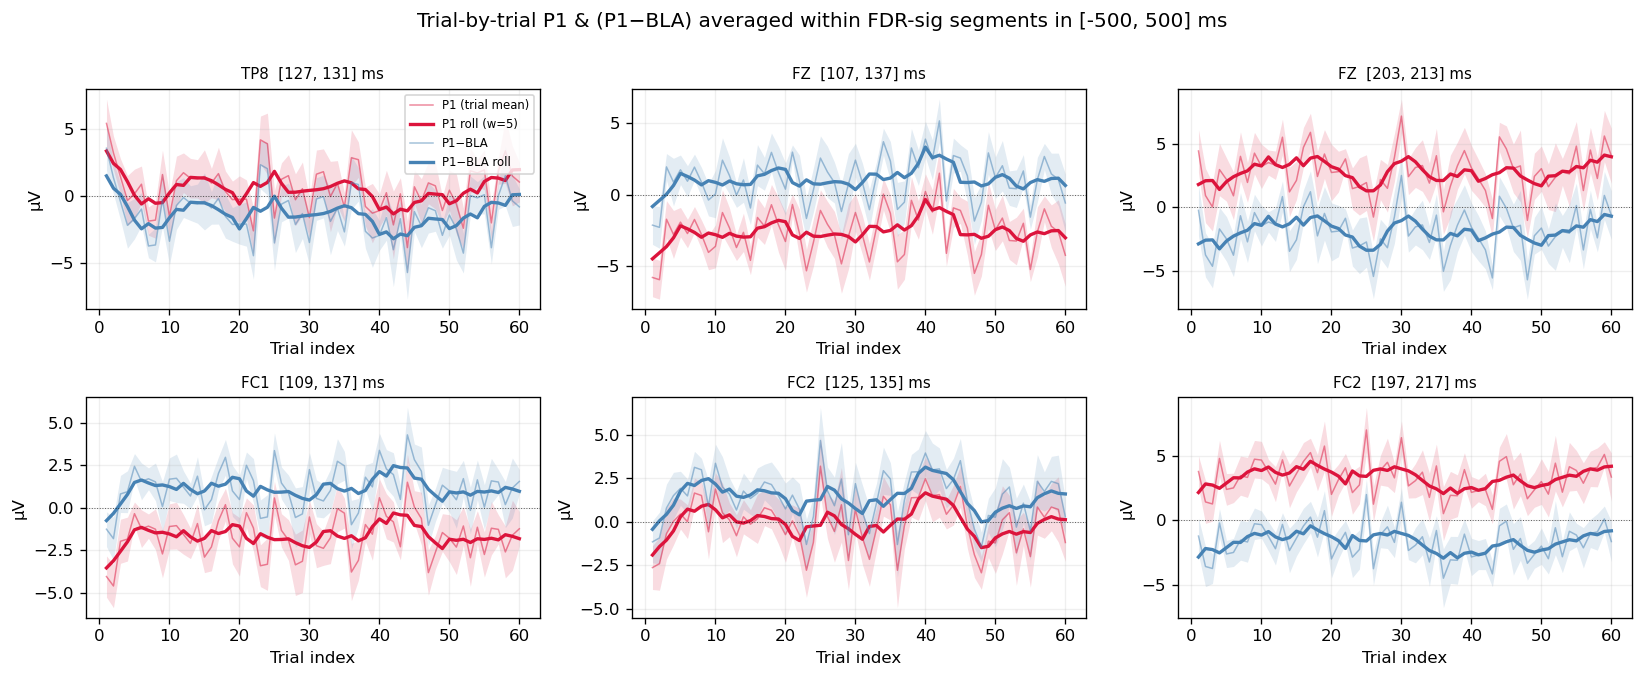


First-10 vs Last-10 trial paired test per (channel, segment):


,channel,segment_ms,metric,n_sub,first10_mean,last10_mean,diff_last-first,paired_t_p,wilcoxon_p
0,TP8,127–131,P1 segment mean,14,0.7304,0.8443,0.1139,0.8862,1.0000
1,TP8,127–131,P1 − BLA segment mean,14,-1.1225,-1.0086,0.1139,0.8862,1.0000
2,FZ,107–137,P1 segment mean,14,-3.3259,-2.8153,0.5106,0.4608,0.7148
3,FZ,107–137,P1 − BLA segment mean,14,0.3468,0.8574,0.5106,0.4608,0.7148
4,FZ,203–213,P1 segment mean,14,2.4817,3.1874,0.7057,0.4612,0.3575
5,FZ,203–213,P1 − BLA segment mean,14,-2.1839,-1.4783,0.7057,0.4612,0.3575
6,FC1,109–137,P1 segment mean,14,-2.0174,-1.8115,0.2059,0.7483,0.7148
7,FC1,109–137,P1 − BLA segment mean,14,0.7713,0.9772,0.2059,0.7483,0.7148
8,FC2,125–135,P1 segment mean,14,-0.0840,-0.2154,-0.1314,0.8114,0.7148
9,FC2,125–135,P1 − BLA segment mean,14,1.3960,1.2646,-0.1314,0.8114,0.7148


In [6]:
# --- §2c: trial dynamics inside §2b FDR-significant segments ---

FIRST_LAST_N = 10  # bin size for first-N vs last-N paired test

assert "sig" in globals() and "time_ms" in globals(), "Run §2b first (needs sig mask + time_ms)."

# Each channel → list of (start_ms, end_ms, start_ix_in_win, end_ix_in_win) segments
seg_by_ch = {}
for c, ch in enumerate(ch_names):
    m = sig[c]
    if not np.any(m):
        continue
    d = np.diff(m.astype(int))
    starts = np.where(d == 1)[0] + 1
    if m[0]:
        starts = np.r_[0, starts]
    ends = np.where(d == -1)[0]
    if m[-1]:
        ends = np.r_[ends, m.size - 1]
    seg_by_ch[ch] = [
        (float(time_ms[i]), float(time_ms[j]), int(i), int(j))
        for i, j in zip(starts, ends)
    ]

n_segs = sum(len(v) for v in seg_by_ch.values())
print(f"{len(seg_by_ch)}/{len(ch_names)} channels have FDR-sig. segments; total {n_segs} segments.")
if n_segs == 0:
    print("No significant segment → skipping trial dynamics.")
else:
    # 把每个被试的试次原始 epoch 窗口也切到 [-500, 500] ms，与 sig 对齐
    t0 = sub_pack[loaded[0]]["times"]
    win_t0 = (t0 * 1000.0 >= FDR_TMIN_MS) & (t0 * 1000.0 <= FDR_TMAX_MS)

    # 对每个 (channel, segment) 预先把段时间索引算好（直接用 §2b 的 i..j, 对齐在 [-500,500] 截窗上）
    # 通用函数：对该被试 × 通道 × 试次 在某段内做时间平均 → 得到 (n_trials,) 序列
    def _seg_mean_trials(sub_id, ch_idx, i, j):
        ep = sub_pack[sub_id]
        x = ep["p1_data"][:, ch_idx, :][:, win_t0]      # (n_trials, Tw)
        return x[:, i:j + 1].mean(axis=1)                # (n_trials,)

    def _seg_mean_bla_subject(sub_id, ch_idx, i, j):
        ep = sub_pack[sub_id]
        x = ep["bla_data"][:, ch_idx, :][:, win_t0].mean(axis=0)  # (Tw,)
        return float(x[i:j + 1].mean())                            # scalar

    # 列出要画的 (ch, seg_index) 面板；为了紧凑，按顺序画
    panels = [(ch, k, s) for ch, segs in seg_by_ch.items() for k, s in enumerate(segs)]
    ncols = 3
    nrows = int(np.ceil(len(panels) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 2.8 * nrows), squeeze=False)
    axs_flat = axs.ravel()

    summary_rows = []

    for p_idx, (ch, k, (t_a, t_b, i_w, j_w)) in enumerate(panels):
        ax = axs_flat[p_idx]
        ch_idx = ch_names.index(ch)

        # 每被试一条 trial 曲线：P1 该段均值 & P1−BLA 该段均值
        per_sub_p1 = []   # list of arrays (n_trials_s,)
        per_sub_diff = []
        for s in loaded:
            vals_p1 = _seg_mean_trials(s, ch_idx, i_w, j_w)
            bla_mean = _seg_mean_bla_subject(s, ch_idx, i_w, j_w)
            per_sub_p1.append(vals_p1)
            per_sub_diff.append(vals_p1 - bla_mean)

        # 统一到最短试次长度，堆叠成 (n_sub, n_tr_min)
        n_tr_min = min(v.size for v in per_sub_p1)
        if n_tr_min < 2:
            ax.set_visible(False)
            continue
        M_p1  = np.stack([v[:n_tr_min] for v in per_sub_p1], axis=0)
        M_dif = np.stack([v[:n_tr_min] for v in per_sub_diff], axis=0)

        trial_idx = np.arange(1, n_tr_min + 1)

        mu_p1  = M_p1.mean(axis=0)
        se_p1  = M_p1.std(axis=0, ddof=1) / np.sqrt(M_p1.shape[0])
        mu_dif = M_dif.mean(axis=0)
        se_dif = M_dif.std(axis=0, ddof=1) / np.sqrt(M_dif.shape[0])

        # 滚动平均
        def _roll(a, w=ROLLING_WINDOW):
            return pd.Series(a).rolling(w, center=True, min_periods=1).mean().values

        ax.fill_between(trial_idx, mu_p1 - se_p1, mu_p1 + se_p1, color="crimson", alpha=0.15, lw=0)
        ax.plot(trial_idx, mu_p1, color="crimson", lw=0.9, alpha=0.5, label="P1 (trial mean)")
        ax.plot(trial_idx, _roll(mu_p1), color="crimson", lw=2.0, label=f"P1 roll (w={ROLLING_WINDOW})")

        ax.fill_between(trial_idx, mu_dif - se_dif, mu_dif + se_dif, color="steelblue", alpha=0.15, lw=0)
        ax.plot(trial_idx, mu_dif, color="steelblue", lw=0.9, alpha=0.5, label="P1−BLA")
        ax.plot(trial_idx, _roll(mu_dif), color="steelblue", lw=2.0, label="P1−BLA roll")

        ax.axhline(0, color="k", ls=":", lw=0.6, alpha=0.6)
        ax.set_title(f"{ch}  [{t_a:.0f}, {t_b:.0f}] ms", fontsize=9)
        ax.set_xlabel("Trial index")
        ax.set_ylabel("µV")
        ax.grid(True, alpha=0.2)
        if p_idx == 0:
            ax.legend(fontsize=7, loc="best")

        # 首-末 N 试次配对 t （每被试先在 first-N / last-N 内取均值，再做 paired t）
        if n_tr_min >= 2 * FIRST_LAST_N:
            first = M_p1[:, :FIRST_LAST_N].mean(axis=1)
            last  = M_p1[:, -FIRST_LAST_N:].mean(axis=1)
            finite = np.isfinite(first) & np.isfinite(last)
            if finite.sum() >= 3:
                tt = stats.ttest_rel(first[finite], last[finite])
                try:
                    wp = float(stats.wilcoxon(first[finite], last[finite]).pvalue)
                except ValueError:
                    wp = np.nan
                summary_rows.append({
                    "channel": ch,
                    "segment_ms": f"{t_a:.0f}–{t_b:.0f}",
                    "metric": "P1 segment mean",
                    "n_sub": int(finite.sum()),
                    "first10_mean": float(first[finite].mean()),
                    "last10_mean":  float(last[finite].mean()),
                    "diff_last-first": float((last[finite] - first[finite]).mean()),
                    "paired_t_p":  float(tt.pvalue),
                    "wilcoxon_p":  wp,
                })

            first_d = M_dif[:, :FIRST_LAST_N].mean(axis=1)
            last_d  = M_dif[:, -FIRST_LAST_N:].mean(axis=1)
            fd = np.isfinite(first_d) & np.isfinite(last_d)
            if fd.sum() >= 3:
                tt = stats.ttest_rel(first_d[fd], last_d[fd])
                try:
                    wp = float(stats.wilcoxon(first_d[fd], last_d[fd]).pvalue)
                except ValueError:
                    wp = np.nan
                summary_rows.append({
                    "channel": ch,
                    "segment_ms": f"{t_a:.0f}–{t_b:.0f}",
                    "metric": "P1 − BLA segment mean",
                    "n_sub": int(fd.sum()),
                    "first10_mean": float(first_d[fd].mean()),
                    "last10_mean":  float(last_d[fd].mean()),
                    "diff_last-first": float((last_d[fd] - first_d[fd]).mean()),
                    "paired_t_p":  float(tt.pvalue),
                    "wilcoxon_p":  wp,
                })

    for k in range(len(panels), nrows * ncols):
        axs_flat[k].set_visible(False)
    fig.suptitle(
        f"Trial-by-trial P1 & (P1−BLA) averaged within FDR-sig segments in [{FDR_TMIN_MS:.0f}, {FDR_TMAX_MS:.0f}] ms",
        y=1.0,
    )
    fig.tight_layout()
    plt.show()

    if summary_rows:
        sum_df = pd.DataFrame(summary_rows)
        print(f"\nFirst-{FIRST_LAST_N} vs Last-{FIRST_LAST_N} trial paired test per (channel, segment):")
        display(sum_df.round(4))
    else:
        print("No segment had enough trials for first/last comparison.")


## 2d. Does the **significant window itself drift across trials**?

§2c fixes the window from the **group-level** FDR (one window per channel). But the significant region may **shift across trial positions** (learning / habituation).  

Here for each **trial position *k*** (optionally smoothed with a **rolling bin** of *W* trials to reduce single-trial noise), we take each subject's **P1 at trial k − that subject's BLA trial mean**, run a **paired *t*** across subjects at **every time sample**, and apply **BH-FDR within the channel × that trial position** over **−500…500 ms**.  

The output per channel is a **(trial × time) heat-map of t-values** with the **FDR-significant pixels outlined**, so you can see if / how the significant band **moves** across trials.

Trial positions used : 60 (min across subjects 60)
Rolling window       : 5 trials (half=2)
Time window          : [-500, 500] ms, n_time=513
FDR α per (ch,trial) : 0.05
  T7    trials_with_sig=3/60  pixels_sig=15/30780
  T8    trials_with_sig=3/60  pixels_sig=10/30780
  TP7   trials_with_sig=3/60  pixels_sig=17/30780
  TP8   trials_with_sig=3/60  pixels_sig=49/30780
  C3    trials_with_sig=1/60  pixels_sig=16/30780
  C4    trials_with_sig=2/60  pixels_sig=21/30780
  CP1   trials_with_sig=0/60  pixels_sig=0/30780
  CP2   trials_with_sig=1/60  pixels_sig=6/30780
  FZ    trials_with_sig=5/60  pixels_sig=71/30780
  FC1   trials_with_sig=2/60  pixels_sig=35/30780
  FC2   trials_with_sig=3/60  pixels_sig=19/30780
  Cz    trials_with_sig=1/60  pixels_sig=4/30780
  CPZ   trials_with_sig=1/60  pixels_sig=11/30780
  F3    trials_with_sig=2/60  pixels_sig=15/30780


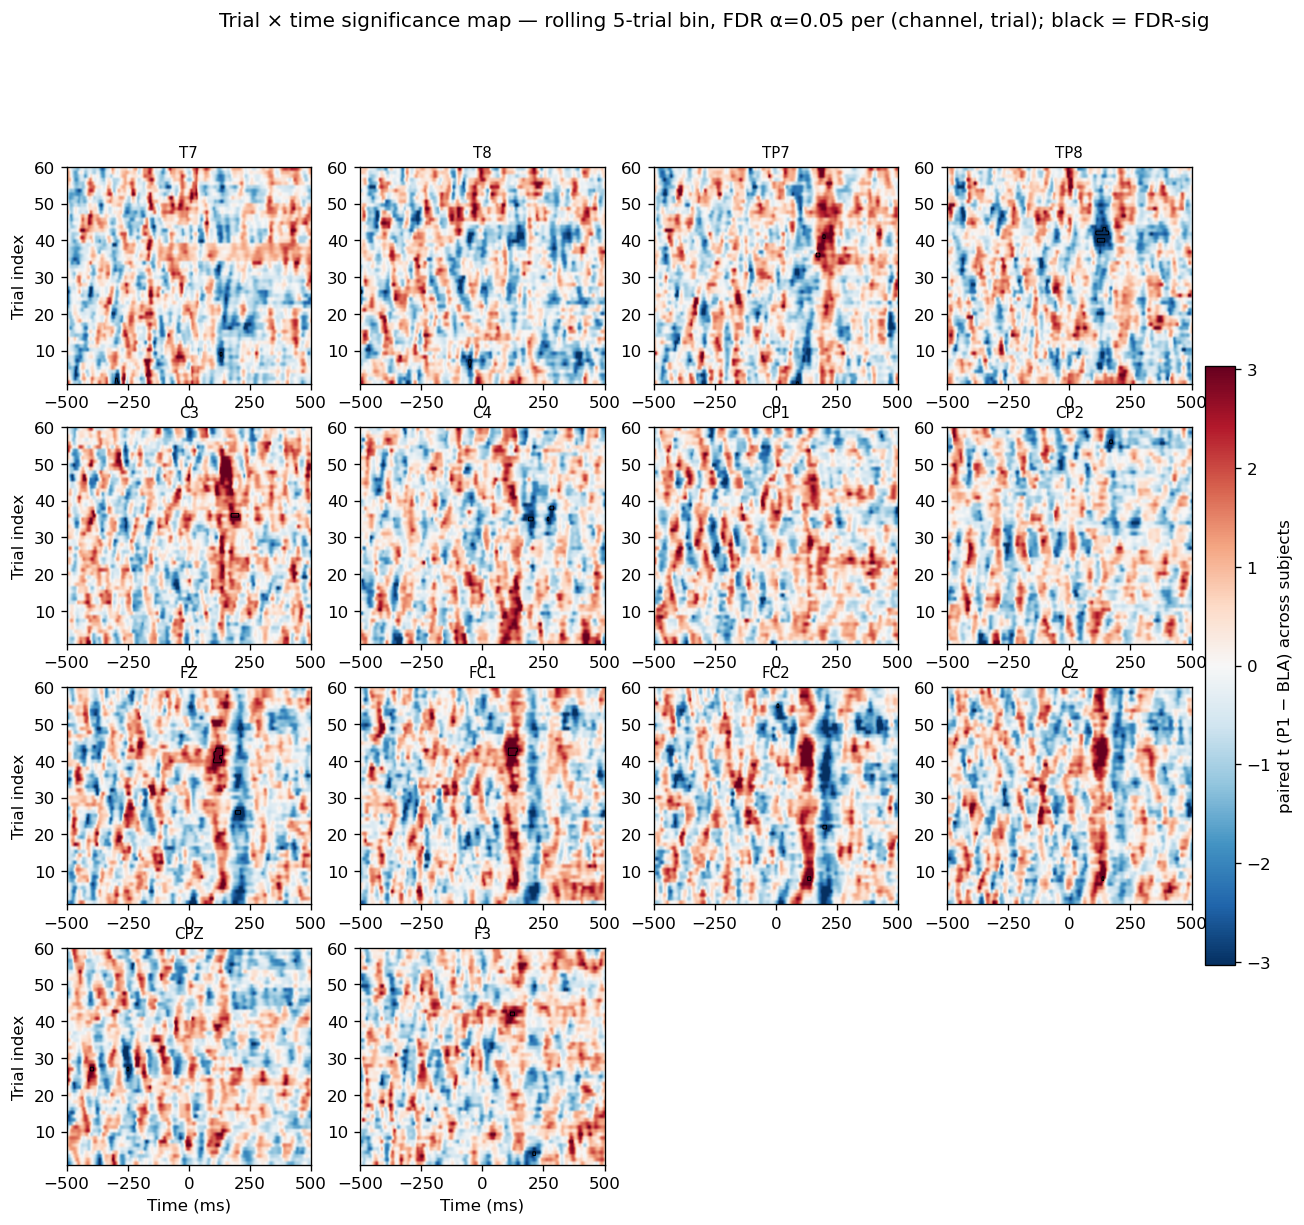

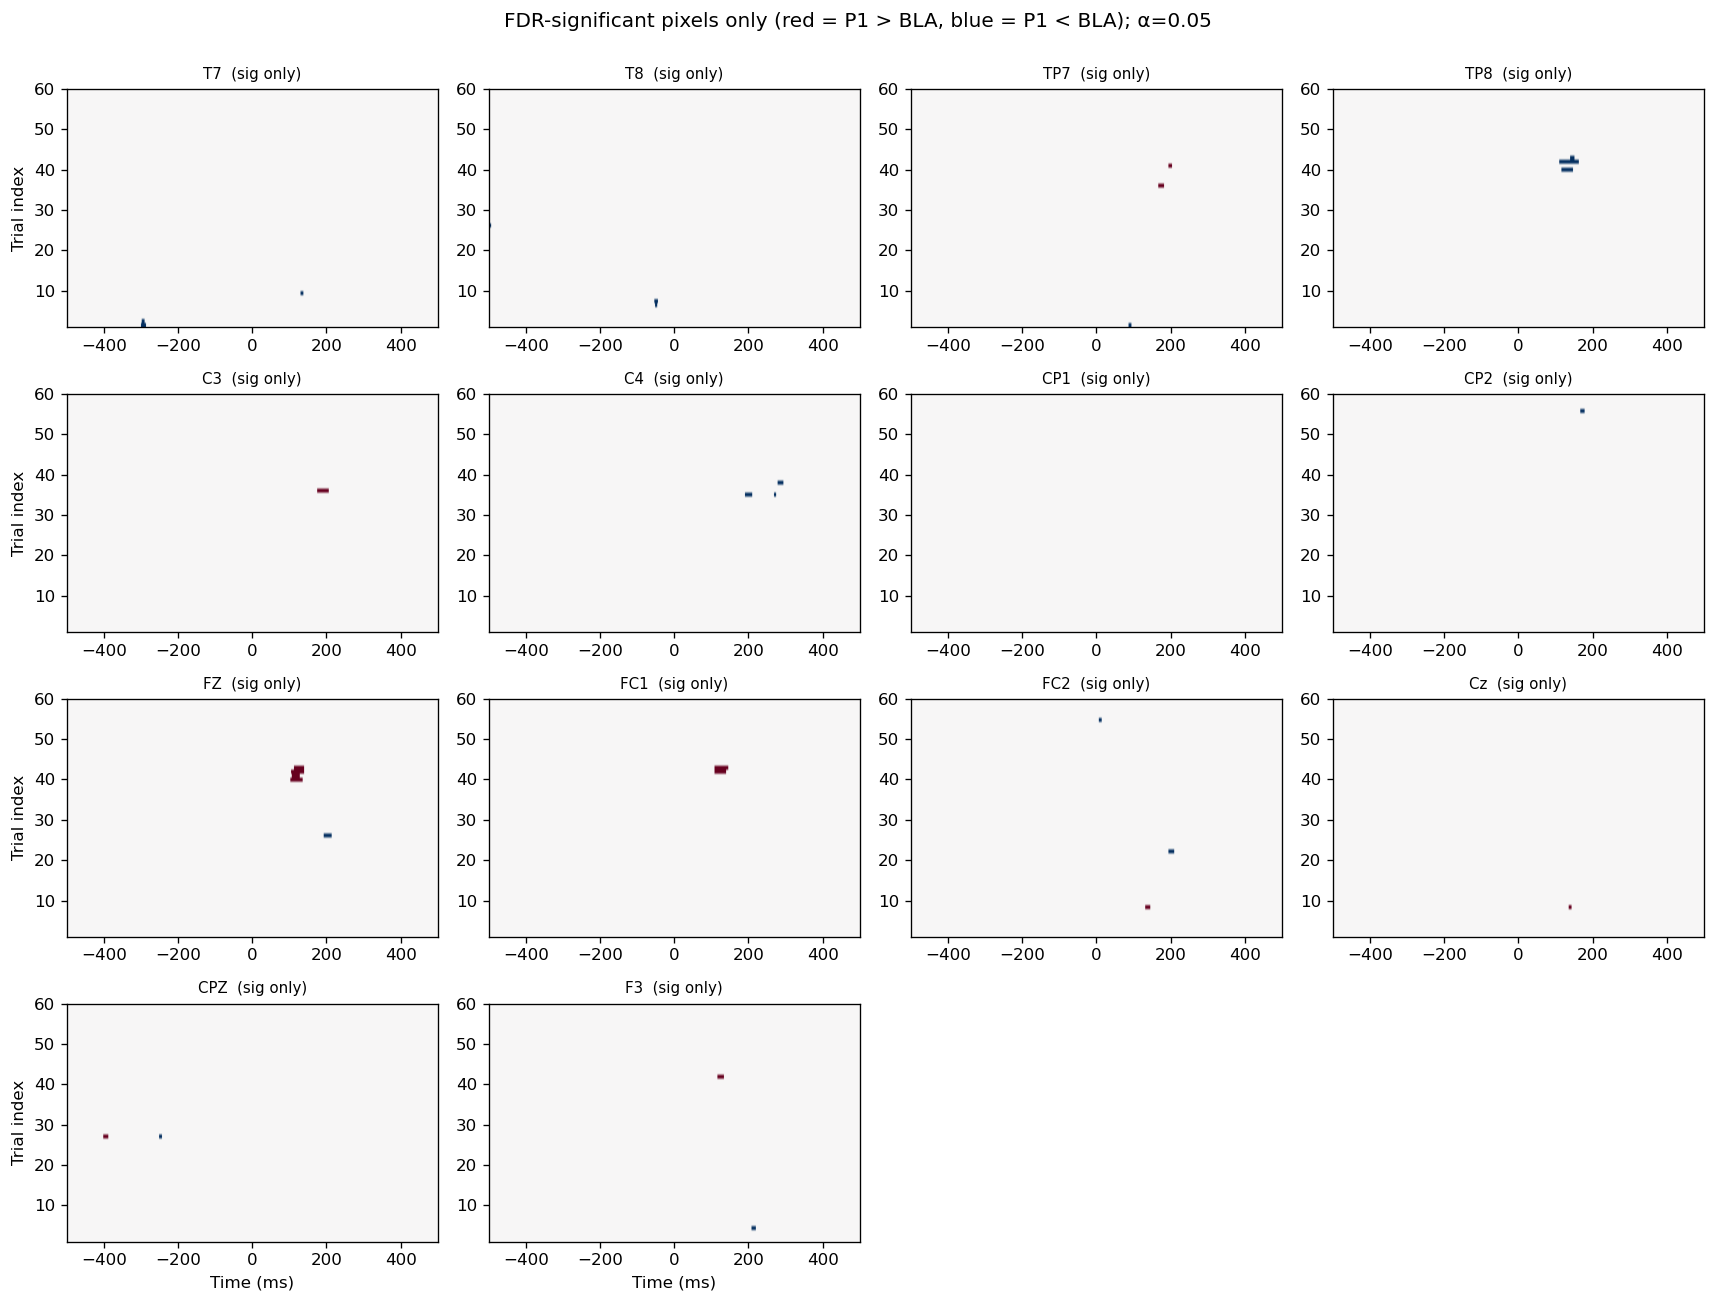


Total (channel, trial, segment) FDR-sig rows: 32

Per channel: # (trial, segment) FDR-sig counts by direction:


sign,P1<BLA,P1>BLA
channel,,
T7,3,0
T8,3,0
TP7,1,2
TP8,3,0
C3,0,1
C4,3,0
CP1,0,0
CP2,1,0
FZ,1,4



Head of the full long table (sorted by channel then trial):


,channel,trial_idx,seg_start_ms,seg_end_ms,width_ms,mean_t,sign
12,C3,36,173.8,203.1,29.3,4.562,P1>BLA
13,C4,35,189.5,207.0,17.6,-4.677,P1<BLA
14,C4,35,267.6,271.5,3.9,-4.181,P1<BLA
15,C4,38,277.3,291.0,13.7,-4.909,P1<BLA
16,CP2,56,166.0,175.8,9.8,-5.331,P1<BLA
28,CPZ,27,-402.3,-390.6,11.7,4.730,P1>BLA
29,CPZ,27,-252.0,-246.1,5.9,-4.369,P1<BLA
27,Cz,8,134.8,140.6,5.9,5.163,P1>BLA
30,F3,4,207.0,216.8,9.8,-4.855,P1<BLA
31,F3,42,115.2,130.9,15.6,4.588,P1>BLA


In [7]:
# --- §2d: per-trial-position significance map (trial × time) ---

TRIAL_ROLL_W = 5          # 每个 trial 位置用 ±(W//2) 邻域平均来降噪；=1 则单试次
FDR_ALPHA_D  = 0.05       # 通道×trial 内部 FDR α
TRIAL_SHOW_MAX = None     # 若非 None，只画前这么多 trial 位置

assert "sig" in globals() and "time_ms" in globals(), "Run §2b first."

# 在 -500..500 ms 内取时间
t0 = sub_pack[loaded[0]]["times"]
win_t = (t0 * 1000.0 >= FDR_TMIN_MS) & (t0 * 1000.0 <= FDR_TMAX_MS)
time_ms_d = t0[win_t] * 1000.0
Tw_d = time_ms_d.size

# 把每个被试切成 (n_trials, n_ch, Tw) 的窗口视图，并把 BLA 每被试 trial 均值也算好
P1_by_sub  = [sub_pack[s]["p1_data"][:, :, win_t] for s in loaded]   # list of (Ntr_s, nch, Tw)
BLA_mean_by_sub = [sub_pack[s]["bla_data"][:, :, win_t].mean(axis=0) for s in loaded]  # list of (nch, Tw)

n_tr_min = int(min(p.shape[0] for p in P1_by_sub))
K = n_tr_min if TRIAL_SHOW_MAX is None else min(TRIAL_SHOW_MAX, n_tr_min)
half = TRIAL_ROLL_W // 2

print(f"Trial positions used : {K} (min across subjects {n_tr_min})")
print(f"Rolling window       : {TRIAL_ROLL_W} trials (half={half})")
print(f"Time window          : [{FDR_TMIN_MS:.0f}, {FDR_TMAX_MS:.0f}] ms, n_time={Tw_d}")
print(f"FDR α per (ch,trial) : {FDR_ALPHA_D}")


def _fdr_bh(p, alpha=0.05):
    p = np.clip(np.asarray(p, dtype=float), 1e-20, 1.0)
    m = p.size
    o = np.argsort(p)
    ps = p[o]
    q = ps * m / (np.arange(1, m + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1.0)
    out = np.empty_like(p)
    out[o] = q
    return out


n_sub = len(loaded)
nch = len(ch_names)

t_map = np.full((nch, K, Tw_d), np.nan)
p_map = np.full((nch, K, Tw_d), np.nan)
q_map = np.full((nch, K, Tw_d), np.nan)

for k in range(K):
    lo = max(0, k - half)
    hi = min(n_tr_min, k + half + 1) if TRIAL_ROLL_W > 1 else k + 1
    # 每被试在这个 trial 位置（或小邻域）上的 P1 平均 — (n_sub, nch, Tw)
    X = np.stack([P1_by_sub[i][lo:hi, :, :].mean(axis=0) for i in range(n_sub)], axis=0)
    B = np.stack(BLA_mean_by_sub, axis=0)                  # (n_sub, nch, Tw)
    D_k = X - B                                            # (n_sub, nch, Tw)
    for c in range(nch):
        tt, pp = stats.ttest_1samp(D_k[:, c, :], 0, axis=0, nan_policy="omit")
        t_map[c, k, :] = tt
        p_map[c, k, :] = np.where(np.isfinite(pp), pp, 1.0)

# 每个 (channel, trial) 内独立做 BH-FDR（对 Tw_d 个时间点）
for c in range(nch):
    for k in range(K):
        q_map[c, k, :] = _fdr_bh(p_map[c, k, :], FDR_ALPHA_D)

sig_map = q_map < FDR_ALPHA_D

# 诊断：每通道有多少个 trial 出现任何显著点
for c, ch in enumerate(ch_names):
    n_trials_sig = int(np.any(sig_map[c], axis=1).sum())
    n_pix = int(sig_map[c].sum())
    print(f"  {ch:4s}  trials_with_sig={n_trials_sig}/{K}  pixels_sig={n_pix}/{K * Tw_d}")

# --- 绘图：每个通道一张 (trial × time) 热图，颜色=t 值，显著像素描边 ---
vmax = float(np.nanpercentile(np.abs(t_map), 99)) if np.isfinite(t_map).any() else 3.0
vmax = max(vmax, 2.5)
ncols = 4
nrows = int(np.ceil(nch / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 2.7 * nrows), squeeze=False)
axs_flat = axs.ravel()

for c, ch in enumerate(ch_names):
    ax = axs_flat[c]
    im = ax.imshow(
        t_map[c],
        aspect="auto",
        origin="lower",
        cmap="RdBu_r",
        vmin=-vmax, vmax=vmax,
        extent=[time_ms_d[0], time_ms_d[-1], 1, K],
    )
    # 用 contour 给 FDR-sig 像素画边
    if np.any(sig_map[c]):
        ax.contour(
            time_ms_d,
            np.arange(1, K + 1),
            sig_map[c].astype(float),
            levels=[0.5],
            colors="k",
            linewidths=0.6,
        )
    ax.set_title(ch, fontsize=9)
    if c // ncols == nrows - 1:
        ax.set_xlabel("Time (ms)")
    if c % ncols == 0:
        ax.set_ylabel("Trial index")
    ax.set_xlim(FDR_TMIN_MS, FDR_TMAX_MS)
for c in range(nch, nrows * ncols):
    axs_flat[c].set_visible(False)

cbar = fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.6, pad=0.01)
cbar.set_label("paired t (P1 − BLA) across subjects")
fig.suptitle(
    f"Trial × time significance map — rolling {TRIAL_ROLL_W}-trial bin, "
    f"FDR α={FDR_ALPHA_D} per (channel, trial); black = FDR-sig",
    y=1.0,
)
plt.show()

# --- Binary FDR-sig map per channel (no t magnitude, colored by sign of t) ---
sign_map = np.sign(t_map) * sig_map.astype(float)   # -1 / 0 / +1
fig2, axs2 = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 2.7 * nrows), squeeze=False)
axs2_flat = axs2.ravel()
for c, ch in enumerate(ch_names):
    ax = axs2_flat[c]
    ax.imshow(
        sign_map[c],
        aspect="auto", origin="lower", cmap="RdBu_r", vmin=-1, vmax=1,
        extent=[time_ms_d[0], time_ms_d[-1], 1, K],
    )
    ax.set_title(f"{ch}  (sig only)", fontsize=9)
    if c // ncols == nrows - 1:
        ax.set_xlabel("Time (ms)")
    if c % ncols == 0:
        ax.set_ylabel("Trial index")
    ax.set_xlim(FDR_TMIN_MS, FDR_TMAX_MS)
for c in range(nch, nrows * ncols):
    axs2_flat[c].set_visible(False)
fig2.suptitle(
    f"FDR-significant pixels only (red = P1 > BLA, blue = P1 < BLA); α={FDR_ALPHA_D}",
    y=1.0,
)
fig2.tight_layout()
plt.show()


# --- Textual summary: per (channel, trial) the FDR-sig time ranges ---
def _mask_to_ranges_ms(mask_1d, t_axis_ms):
    m = np.asarray(mask_1d, dtype=bool)
    if not m.any():
        return []
    d = np.diff(m.astype(int))
    s = np.where(d == 1)[0] + 1
    if m[0]:
        s = np.r_[0, s]
    e = np.where(d == -1)[0]
    if m[-1]:
        e = np.r_[e, m.size - 1]
    return [(float(t_axis_ms[i]), float(t_axis_ms[j])) for i, j in zip(s, e)]


# Long-form DataFrame: one row per (channel, trial_idx, segment)
rows = []
for c, ch in enumerate(ch_names):
    for k in range(K):
        rngs = _mask_to_ranges_ms(sig_map[c, k, :], time_ms_d)
        if not rngs:
            continue
        for t_a, t_b in rngs:
            a_ix = np.searchsorted(time_ms_d, t_a)
            b_ix = np.searchsorted(time_ms_d, t_b)
            seg_t = t_map[c, k, a_ix : b_ix + 1]
            if seg_t.size == 0:
                continue
            mean_t = float(np.nanmean(seg_t))
            sign_tag = "P1>BLA" if mean_t > 0 else "P1<BLA"
            rows.append({
                "channel": ch,
                "trial_idx": k + 1,
                "seg_start_ms": round(t_a, 1),
                "seg_end_ms":   round(t_b, 1),
                "width_ms":     round(t_b - t_a, 1),
                "mean_t":       round(mean_t, 3),
                "sign":         sign_tag,
            })

fdr_trial_segments_df = pd.DataFrame(rows)
print(f"\nTotal (channel, trial, segment) FDR-sig rows: {len(fdr_trial_segments_df)}")
if len(fdr_trial_segments_df):
    # Per channel counts
    cnt = (
        fdr_trial_segments_df.groupby(["channel", "sign"])
        .size().unstack(fill_value=0).reindex(ch_names, fill_value=0)
    )
    print("\nPer channel: # (trial, segment) FDR-sig counts by direction:")
    display(cnt)
    print("\nHead of the full long table (sorted by channel then trial):")
    display(
        fdr_trial_segments_df.sort_values(["channel", "trial_idx", "seg_start_ms"]).head(30)
    )
else:
    print("No FDR-sig (channel, trial, time) pixels at current α / rolling-W.")


## 3. N1/P2 comparability between BLA and P1 (auditory ROI)

If P1 N1/P2 is very different from BLA N1/P2, the auditory ERP itself has changed (attention-on-N1 confound) and the residual will carry that difference. β absorbs part of the amplitude mismatch, but large shape/latency differences cannot be scaled away.

In [8]:
N1_WINDOW = (0.080, 0.160)
P2_WINDOW = (0.150, 0.250)


def _peak_amp_roi(data, times, roi_ix, window, polarity):
    m = (times >= window[0]) & (times <= window[1])
    seg = data[:, roi_ix, :][:, :, m].mean(axis=1)   # (trials, t)
    return seg.max(axis=-1) if polarity == "pos" else seg.min(axis=-1)


rows = []
for sub_id in loaded:
    pack = sub_pack[sub_id]
    aud_ix = [pack["ch_names"].index(c) for c in ROI_AUDITORY if c in pack["ch_names"]]
    for comp, win, pol in [("N1", N1_WINDOW, "neg"), ("P2", P2_WINDOW, "pos")]:
        a_p1  = _peak_amp_roi(pack["p1_data"],  pack["times"], aud_ix, win, pol)
        a_bla = _peak_amp_roi(pack["bla_data"], pack["times"], aud_ix, win, pol)
        rows.append({
            "sub_id": sub_id,
            "component": comp,
            "p1_mean":  float(np.mean(a_p1)),
            "bla_mean": float(np.mean(a_bla)),
            "diff":     float(np.mean(a_p1) - np.mean(a_bla)),
        })

comp_df = pd.DataFrame(rows)

print("Within-subject P1 − BLA peak at T+TP:")
for comp, g in comp_df.groupby("component"):
    t = stats.ttest_rel(g["p1_mean"], g["bla_mean"])
    print(f"  {comp:3s}: mean diff = {g['diff'].mean():+.3f} µV | paired t p = {t.pvalue:.3g}")

display(comp_df.pivot(index="sub_id", columns="component", values="diff").round(2))


Within-subject P1 − BLA peak at T+TP:
  N1 : mean diff = -0.387 µV | paired t p = 0.393
  P2 : mean diff = +0.018 µV | paired t p = 0.955


component,N1,P2
sub_id,,
2,-2.42,-0.91
3,-0.71,1.42
5,-0.35,0.80
6,-0.94,1.64
7,-0.58,0.12
8,1.80,-0.95
9,0.07,1.33
10,-1.74,-0.39
11,-2.03,-0.02


## 4. Regression residuals

For each P1 trial × channel we fit $\beta$ by OLS **without intercept** on the auditory-dominated window **0–200 ms**:
$$\beta = \frac{\langle \text{template}_{0..200}, \text{P1}_{0..200}\rangle}{\langle \text{template}_{0..200}, \text{template}_{0..200}\rangle}$$

The residual is then defined for the full epoch:
$$\text{residual}(t) = \text{P1}(t) - \beta \cdot \text{template}(t)$$

By construction the residual at 200–500 ms is **not** the scaled auditory ERP.

β across trials × channels × subjects: n=11760, median=0.784, IQR=[0.314, 1.297]
β near 1 = P1 auditory ERP matches BLA template; β > 1 = attention-on-N1/P2 amplification.


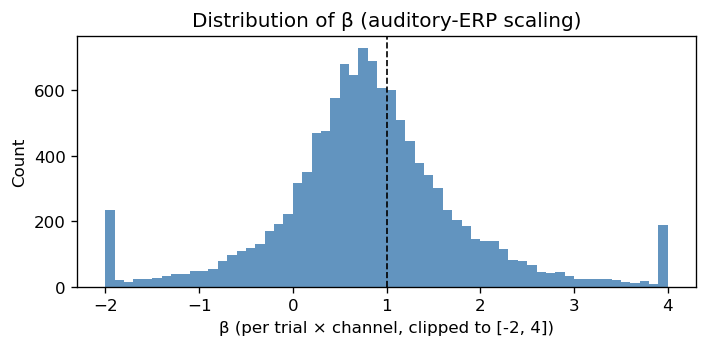

In [9]:
def _fit_beta(y_fit, x_fit, eps=1e-20):
    denom = float(np.dot(x_fit, x_fit))
    if denom < eps:
        return 1.0
    return float(np.dot(x_fit, y_fit) / denom)


for sub_id in loaded:
    pack  = sub_pack[sub_id]
    p1    = pack["p1_data"]          # (n_trials, n_ch, n_t)
    tpl   = templates[sub_id]         # (n_ch, n_t)
    times = pack["times"]

    fit_mask = (times >= AUD_FIT_TMIN) & (times <= AUD_FIT_TMAX)
    n_tr, n_ch, _ = p1.shape

    betas = np.zeros((n_tr, n_ch))
    resid = np.empty_like(p1)
    for tr in range(n_tr):
        for c in range(n_ch):
            b = _fit_beta(p1[tr, c, fit_mask], tpl[c, fit_mask])
            betas[tr, c] = b
            resid[tr, c, :] = p1[tr, c, :] - b * tpl[c, :]

    pack["betas"]    = betas
    pack["residual"] = resid

all_betas = np.concatenate([sub_pack[s]["betas"].ravel() for s in loaded])
print(f"β across trials × channels × subjects: n={len(all_betas)}, "
      f"median={np.median(all_betas):.3f}, IQR=[{np.percentile(all_betas, 25):.3f}, {np.percentile(all_betas, 75):.3f}]")
print("β near 1 = P1 auditory ERP matches BLA template; β > 1 = attention-on-N1/P2 amplification.")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(np.clip(all_betas, -2, 4), bins=60, color="steelblue", alpha=0.85)
ax.axvline(1.0, color="k", ls="--", lw=1)
ax.set_xlabel("β (per trial × channel, clipped to [-2, 4])")
ax.set_ylabel("Count")
ax.set_title("Distribution of β (auditory-ERP scaling)")
plt.tight_layout()
plt.show()


## 5. Grand-average residual: C+CP (anticipation) vs T+TP (negative control)

ValueError: x and y must have same first dimension, but have shapes (513,) and (1792,)

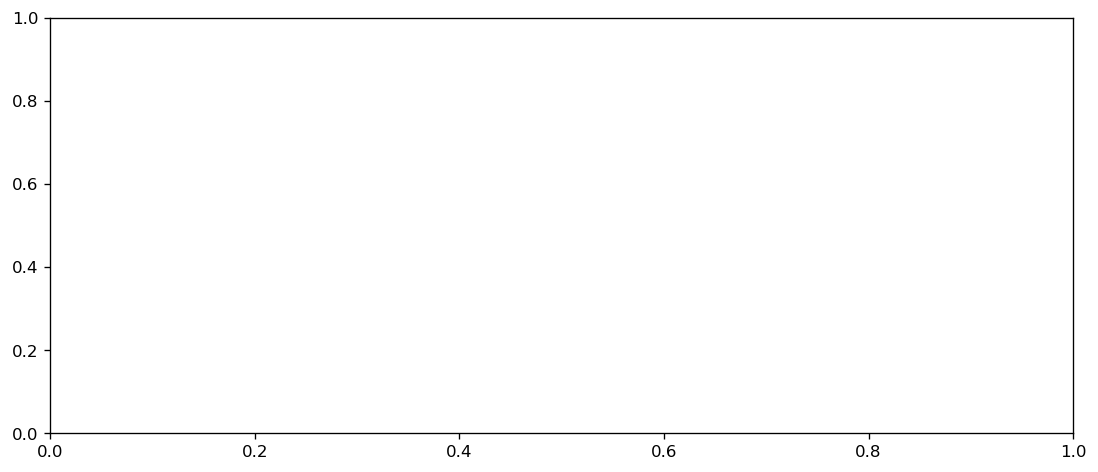

In [10]:
ga_resid = np.stack([sub_pack[s]["residual"].mean(axis=0) for s in loaded]).mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
for lab, roi, color in [
    ("T+TP (negative control)",        ROI_AUDITORY, "#1f77b4"),
    ("C+CP (somato-anticipation)",     ROI_CENTRAL,  "crimson"),
    ("FCmid (CNV core)",               ROI_FC_MID,   "seagreen"),
    ("F3 (left dlPFC)",                ROI_F3,       "darkorange"),
]:
    ax.plot(time_ms, _roi_mean(ga_resid, roi), lw=2.3, color=color, label=lab)
ax.axhline(0,   color="gray", ls=":", lw=0.8)
ax.axvline(0,   color="k",    ls="--", lw=0.8, alpha=0.6)
ax.axvline(500, color="k",    ls=":",  lw=0.8, alpha=0.6)
ax.axvspan(ANT_TMIN*1000, ANT_TMAX*1000, alpha=0.15, color="gold", label="Anticipation window")
ax.set_xlim(-200, 900)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Residual µV  (P1 − β·BLA)")
ax.set_title("Grand-average regression residual")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 6. Per-trial anticipation features

- **Time-domain (on residual):** mean amp 200–500 ms, CNV slope 200–500 ms (linear regression).
- **Frequency-domain (on raw P1):** α (8–13 Hz) and β (13–30 Hz) ERD in dB vs baseline (Welch).

In [ ]:
def _cnv_slope(y, t_s):
    m = np.isfinite(y) & np.isfinite(t_s)
    if m.sum() < 3:
        return np.nan
    return float(stats.linregress(t_s[m], y[m]).slope)


def _bandpass_mean_power(x, sfreq, lo, hi, order=4):
    """Zero-phase Butterworth band-pass + Hilbert envelope → mean instantaneous power.

    Well-defined for short windows where Welch has too few frequency bins."""
    x = np.asarray(x, dtype=float)
    if x.size < max(8, order * 3):
        return np.nan
    ny = sfreq / 2.0
    lo_n = max(lo / ny, 1e-4)
    hi_n = min(hi / ny, 0.999)
    if hi_n <= lo_n:
        return np.nan
    b, a = butter(order, [lo_n, hi_n], btype="band")
    y = filtfilt(b, a, x)
    return float(np.mean(np.abs(hilbert(y)) ** 2))


def _db(post, base, eps=1e-20):
    return 10.0 * np.log10((post + eps) / (base + eps))


rows = []
for sub_id in loaded:
    pack  = sub_pack[sub_id]
    times = pack["times"]
    sfreq = pack["sfreq"]
    ch_names_s = pack["ch_names"]
    resid = pack["residual"]
    raw   = pack["p1_data"]

    ant_mask  = (times >= ANT_TMIN)      & (times <= ANT_TMAX)
    base_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)
    t_ant = times[ant_mask]

    roi_map = {
        "T+TP":  ROI_AUDITORY,
        "C+CP":  ROI_CENTRAL,
        "FCmid": ROI_FC_MID,
        "F3roi": ROI_F3,
        **REGIONS,
    }
    roi_ix = {r: [ch_names_s.index(c) for c in chs if c in ch_names_s] for r, chs in roi_map.items()}

    for tr in range(resid.shape[0]):
        row = {"sub_id": sub_id, "trial_index": tr + 1}
        for roi, ix in roi_ix.items():
            if not ix:
                continue
            resid_ant = resid[tr, ix, :][:, ant_mask].mean(axis=0)
            row[f"{roi}_resid_mean_ant"]  = float(np.mean(resid_ant))
            row[f"{roi}_resid_cnv_slope"] = _cnv_slope(resid_ant, t_ant)

            base_seg = raw[tr, ix, :][:, base_mask].mean(axis=0)
            post_seg = raw[tr, ix, :][:, ant_mask].mean(axis=0)
            for bname, (lo, hi) in BANDS_ERD.items():
                bp_base = _bandpass_mean_power(base_seg, sfreq, lo, hi)
                bp_post = _bandpass_mean_power(post_seg, sfreq, lo, hi)
                row[f"{roi}_{bname}_db"] = _db(bp_post, bp_base)
        rows.append(row)

features_df = pd.DataFrame(rows)
print("features_df:", features_df.shape)
display(features_df.head())


features_df: (840, 58)


,sub_id,trial_index,T+TP_resid_mean_ant,T+TP_resid_cnv_slope,T+TP_alpha_db,T+TP_beta_db,C+CP_resid_mean_ant,C+CP_resid_cnv_slope,C+CP_alpha_db,C+CP_beta_db,...,Cz_alpha_db,Cz_beta_db,CPZ_resid_mean_ant,CPZ_resid_cnv_slope,CPZ_alpha_db,CPZ_beta_db,F3_resid_mean_ant,F3_resid_cnv_slope,F3_alpha_db,F3_beta_db
0,2,1,-4.919308,50.557141,10.211474,2.724150,-1.372015,-29.014441,-8.457122,1.275364,...,1.455291,3.783210,0.110262,-32.919877,-1.870968,-3.164865,5.798636,-32.108489,-6.504984,1.928489
1,2,2,-0.589399,4.940931,-7.647436,-1.661147,-1.636525,-8.474308,-15.149134,0.382122,...,-7.873169,-0.513057,0.266949,-24.718740,-12.092021,0.350186,-1.381676,27.102066,-14.407484,-1.907316
2,2,3,0.336028,3.055047,-23.719983,-2.538658,-0.274178,-6.135815,-5.911387,-3.665955,...,-13.436653,-0.979209,1.990627,11.310978,-2.191897,-3.699399,1.742049,-7.686397,-0.027454,-1.109845
3,2,4,1.369739,-15.233522,3.892206,0.433888,-1.752570,4.827999,-5.554928,-1.696710,...,2.232448,-0.647978,0.165211,11.307943,-7.385238,-5.379759,2.535678,42.501338,-3.591735,-1.283541
4,2,5,-0.266786,-3.973951,-2.305231,1.433091,-0.581050,-9.974081,-5.971844,-0.134291,...,1.319660,-2.644656,2.629643,20.800178,-3.349668,-1.212733,0.294757,17.619440,4.895873,-0.922824


## 7. Trial-by-trial dynamics (rolling + OLS fit) — C+CP core indicators

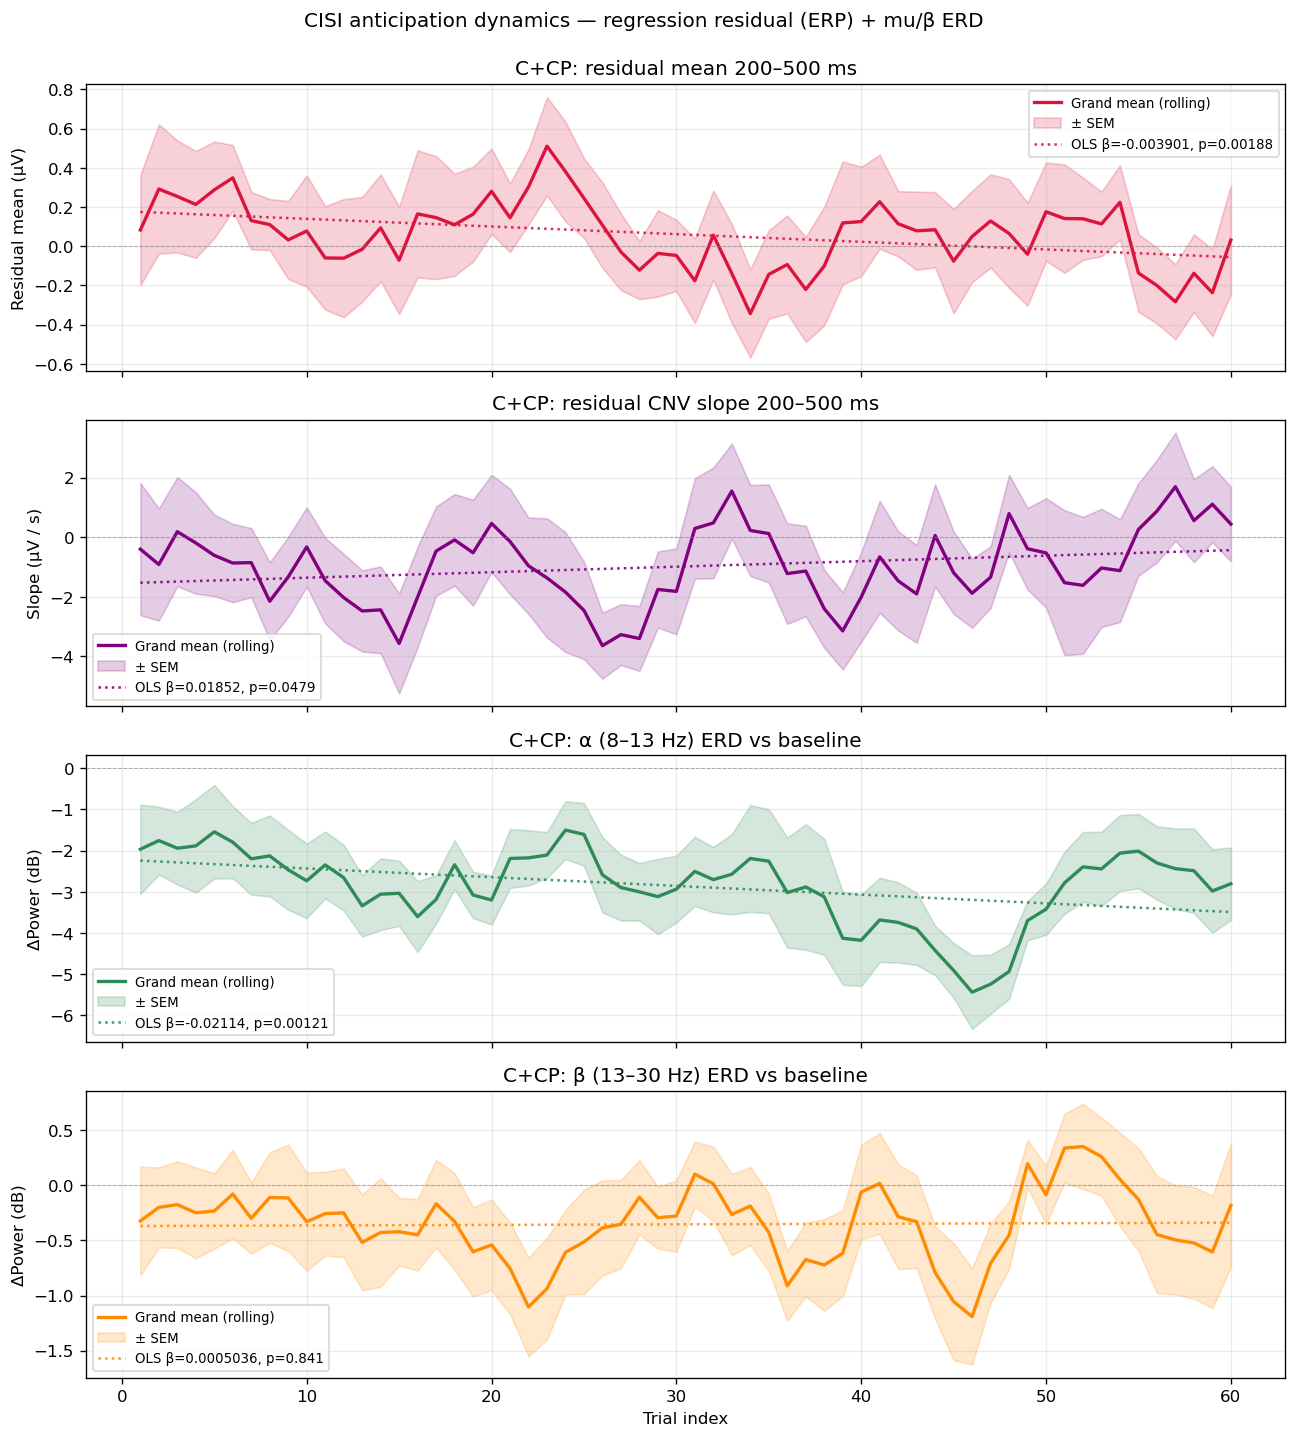

In [ ]:
value_cols = [c for c in features_df.columns if c not in ("sub_id", "trial_index")]

roll_chunks = []
for sub_id, g in features_df.groupby("sub_id"):
    g = g.sort_values("trial_index").reset_index(drop=True)
    for col in value_cols:
        g[f"{col}_roll"] = g[col].rolling(ROLLING_WINDOW, center=True, min_periods=1).mean()
    roll_chunks.append(g)
roll_df = pd.concat(roll_chunks, ignore_index=True)

group_df = roll_df.groupby("trial_index")[[f"{c}_roll" for c in value_cols]].agg(["mean", "sem"])


def _plot_core(col, ylab, title, ax, color):
    mean = group_df[f"{col}_roll"]["mean"]
    sem  = group_df[f"{col}_roll"]["sem"]
    idx  = mean.index.values.astype(float)
    ax.plot(idx, mean, color=color, lw=2, label="Grand mean (rolling)")
    ax.fill_between(idx, mean - sem, mean + sem, color=color, alpha=0.2, label="± SEM")

    m = np.isfinite(mean.values) & np.isfinite(idx)
    if m.sum() > 3:
        r = stats.linregress(idx[m], mean.values[m])
        ax.plot(idx, r.intercept + r.slope * idx, ls=":", color=color, lw=1.5, alpha=0.9,
                label=f"OLS β={r.slope:.4g}, p={r.pvalue:.3g}")
    ax.axhline(0, color="gray", lw=0.6, ls="--", alpha=0.6)
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)


fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)
_plot_core("C+CP_resid_mean_ant",  "Residual mean (µV)",  "C+CP: residual mean 200–500 ms",            axes[0], "crimson")
_plot_core("C+CP_resid_cnv_slope", "Slope (µV / s)",      "C+CP: residual CNV slope 200–500 ms",       axes[1], "purple")
_plot_core("C+CP_alpha_db",        "ΔPower (dB)",         "C+CP: α (8–13 Hz) ERD vs baseline",         axes[2], "seagreen")
_plot_core("C+CP_beta_db",         "ΔPower (dB)",         "C+CP: β (13–30 Hz) ERD vs baseline",        axes[3], "darkorange")
axes[-1].set_xlabel("Trial index")
fig.suptitle("CISI anticipation dynamics — regression residual (ERP) + mu/β ERD", y=0.995)
fig.tight_layout()
plt.show()


### Same four indicators on **FC midline** (Fz/FCz/Cz — CNV core)

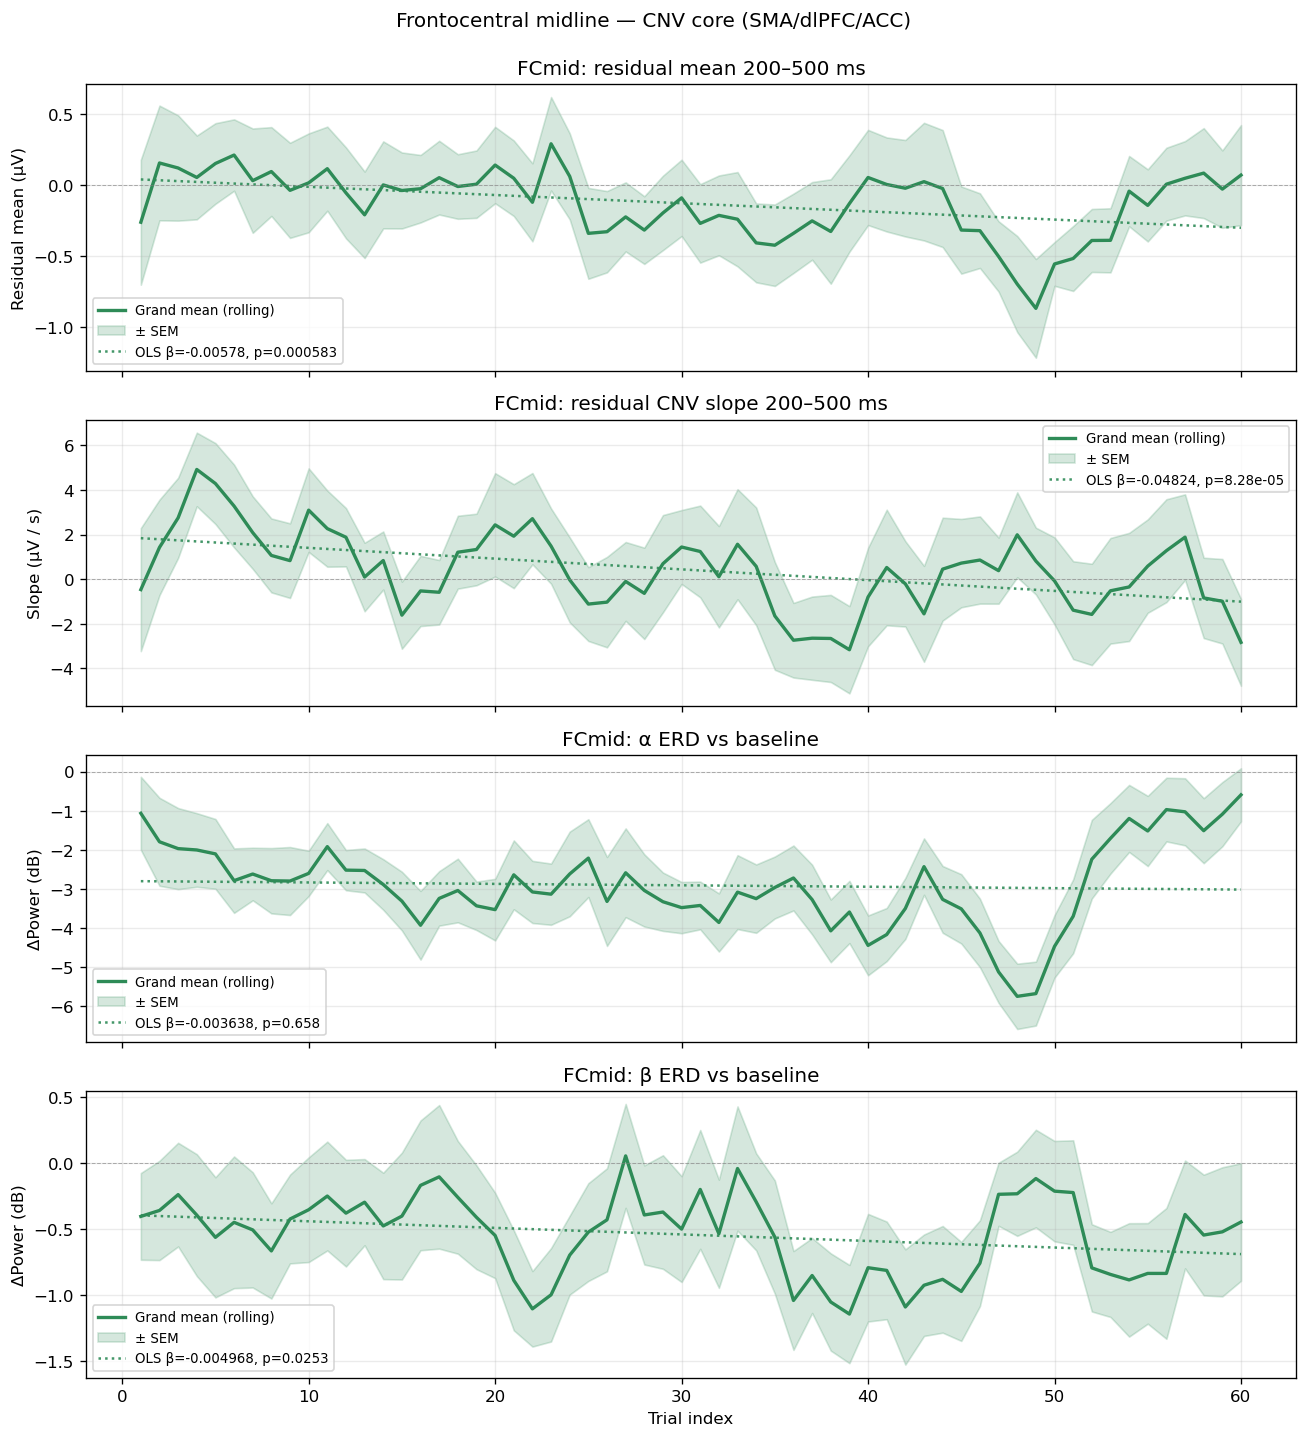

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)
_plot_core("FCmid_resid_mean_ant",  "Residual mean (µV)", "FCmid: residual mean 200–500 ms",        axes[0], "seagreen")
_plot_core("FCmid_resid_cnv_slope", "Slope (µV / s)",     "FCmid: residual CNV slope 200–500 ms",   axes[1], "seagreen")
_plot_core("FCmid_alpha_db",        "ΔPower (dB)",        "FCmid: α ERD vs baseline",                axes[2], "seagreen")
_plot_core("FCmid_beta_db",         "ΔPower (dB)",        "FCmid: β ERD vs baseline",                axes[3], "seagreen")
axes[-1].set_xlabel("Trial index")
fig.suptitle("Frontocentral midline — CNV core (SMA/dlPFC/ACC)", y=0.995)
fig.tight_layout()
plt.show()


### Same four indicators on **F3** (left dlPFC — attention/WM component of anticipation)

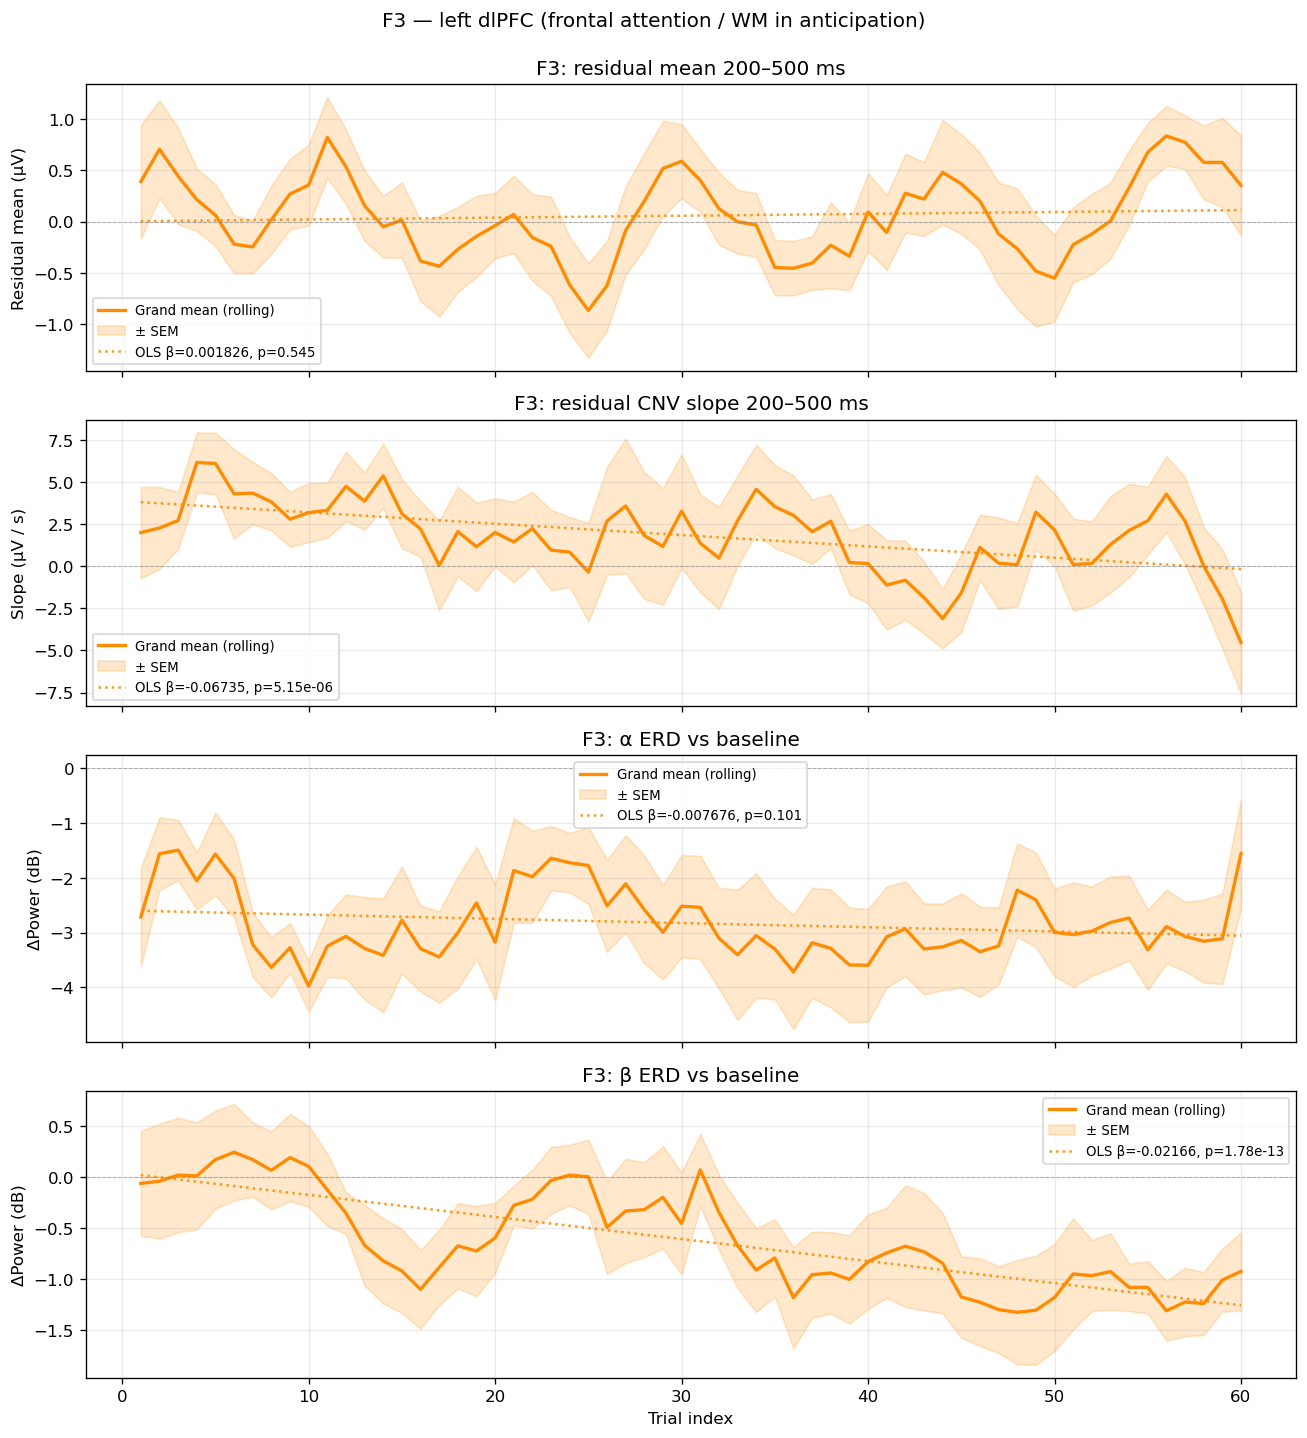

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)
_plot_core("F3roi_resid_mean_ant",  "Residual mean (µV)", "F3: residual mean 200–500 ms",       axes[0], "darkorange")
_plot_core("F3roi_resid_cnv_slope", "Slope (µV / s)",     "F3: residual CNV slope 200–500 ms",  axes[1], "darkorange")
_plot_core("F3roi_alpha_db",        "ΔPower (dB)",        "F3: α ERD vs baseline",                axes[2], "darkorange")
_plot_core("F3roi_beta_db",         "ΔPower (dB)",        "F3: β ERD vs baseline",                axes[3], "darkorange")
axes[-1].set_xlabel("Trial index")
fig.suptitle("F3 — left dlPFC (frontal attention / WM in anticipation)", y=0.995)
fig.tight_layout()
plt.show()


### Same four indicators on **T+TP** (negative control — should be flat/weaker)

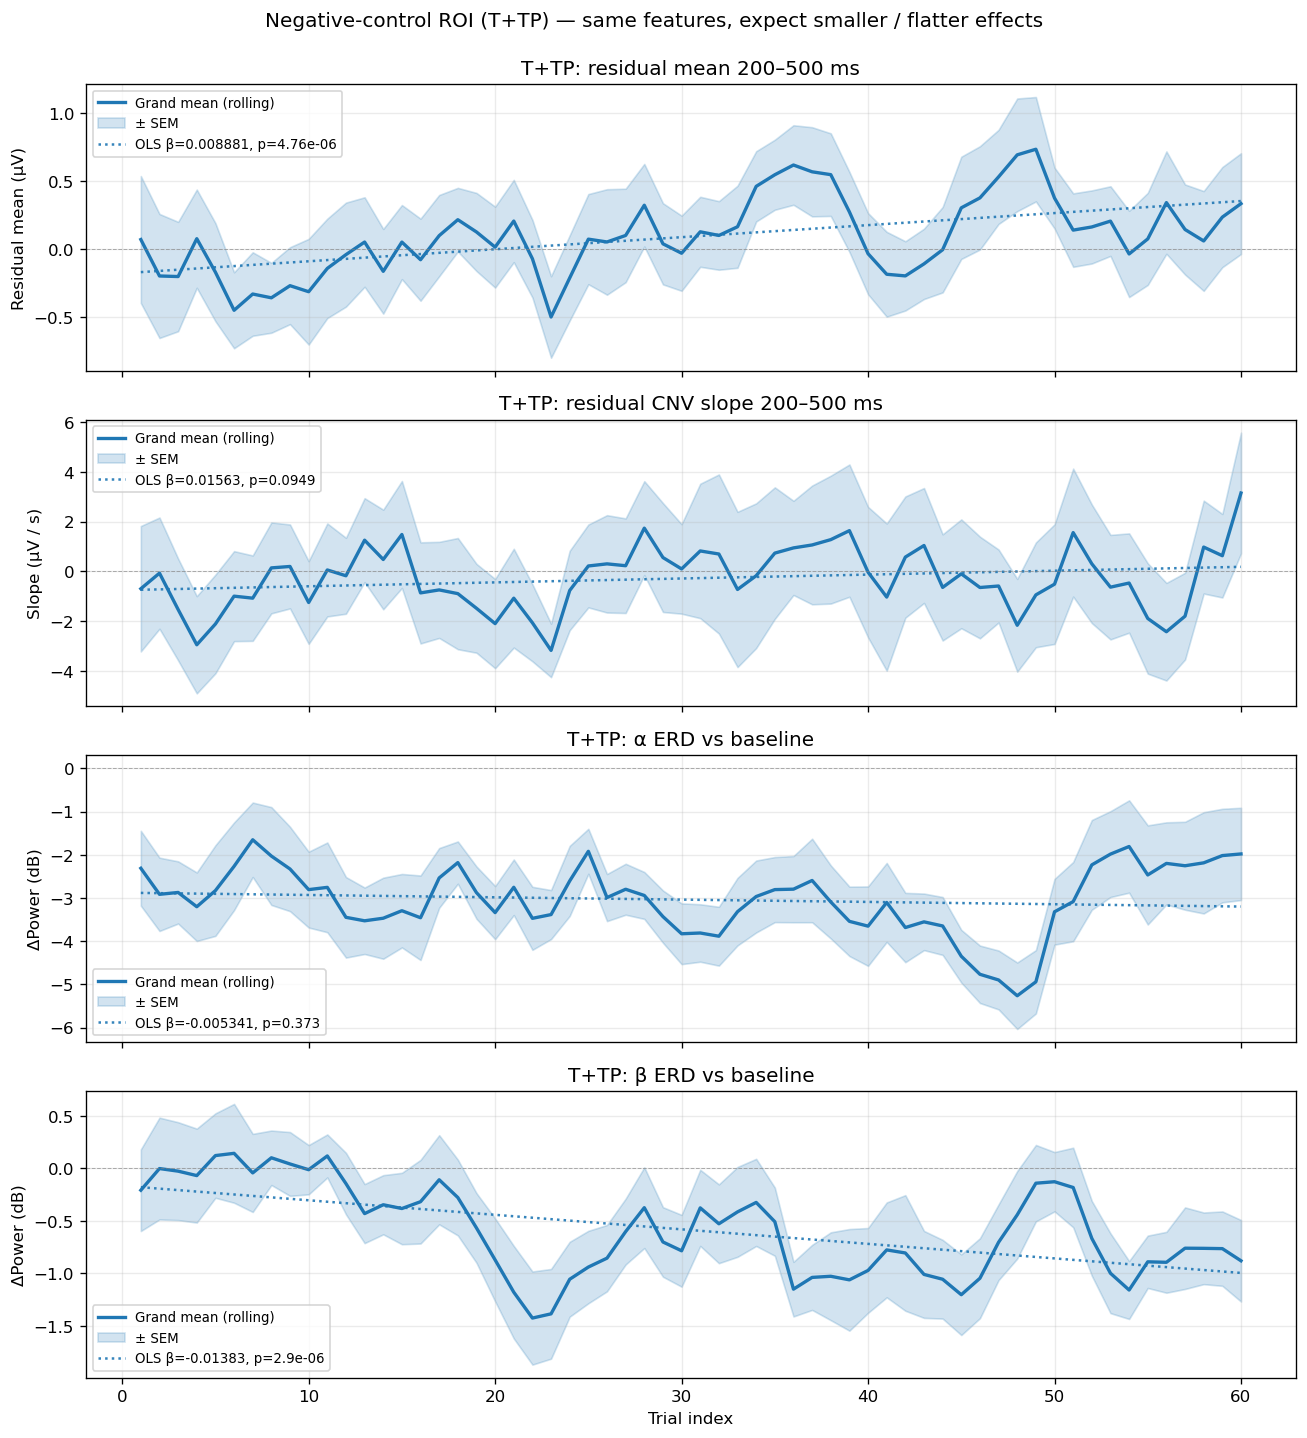

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)
_plot_core("T+TP_resid_mean_ant",  "Residual mean (µV)", "T+TP: residual mean 200–500 ms",         axes[0], "#1f77b4")
_plot_core("T+TP_resid_cnv_slope", "Slope (µV / s)",     "T+TP: residual CNV slope 200–500 ms",    axes[1], "#1f77b4")
_plot_core("T+TP_alpha_db",        "ΔPower (dB)",        "T+TP: α ERD vs baseline",                 axes[2], "#1f77b4")
_plot_core("T+TP_beta_db",         "ΔPower (dB)",        "T+TP: β ERD vs baseline",                 axes[3], "#1f77b4")
axes[-1].set_xlabel("Trial index")
fig.suptitle("Negative-control ROI (T+TP) — same features, expect smaller / flatter effects", y=0.995)
fig.tight_layout()
plt.show()


## 8. First-10 vs last-10 paired tests (learning-related change)

In [ ]:
BIN = 10
out_rows = []

FEATURES_TO_TEST = [
    "FCmid_resid_mean_ant", "FCmid_resid_cnv_slope", "FCmid_alpha_db", "FCmid_beta_db",
    "F3roi_resid_mean_ant", "F3roi_resid_cnv_slope", "F3roi_alpha_db", "F3roi_beta_db",
    "C+CP_resid_mean_ant",  "C+CP_resid_cnv_slope",  "C+CP_alpha_db",  "C+CP_beta_db",
    "T+TP_resid_mean_ant",  "T+TP_resid_cnv_slope",  "T+TP_alpha_db",  "T+TP_beta_db",
]

for col in FEATURES_TO_TEST:
    firsts, lasts = [], []
    for sub_id, g in features_df.groupby("sub_id"):
        g = g.sort_values("trial_index")
        tmax = int(g["trial_index"].max())
        if tmax < 2 * BIN:
            continue
        firsts.append(g.loc[g["trial_index"] <= BIN, col].mean())
        lasts.append(g.loc[g["trial_index"] > tmax - BIN, col].mean())
    a, b = np.array(firsts, dtype=float), np.array(lasts, dtype=float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        out_rows.append({"feature": col, "n_sub": int(m.sum()), "note": "too few"})
        continue
    t = stats.ttest_rel(a[m], b[m])
    try:
        wp = float(stats.wilcoxon(a[m], b[m]).pvalue)
    except ValueError:
        wp = np.nan
    out_rows.append({
        "feature":           col,
        "n_sub":             int(m.sum()),
        "mean_first10":      float(a[m].mean()),
        "mean_last10":       float(b[m].mean()),
        "diff_last-first":   float((b[m] - a[m]).mean()),
        "paired_t_p":        float(t.pvalue),
        "wilcoxon_p":        wp,
    })

display(pd.DataFrame(out_rows).round(4))


,feature,n_sub,mean_first10,mean_last10,diff_last-first,paired_t_p,wilcoxon_p
0,FCmid_resid_mean_ant,14,0.1077,-0.1530,-0.2607,0.2511,0.2166
1,FCmid_resid_cnv_slope,14,1.9070,-0.6816,-2.5886,0.1588,0.2166
2,FCmid_alpha_db,14,-2.3777,-1.6068,0.7709,0.3294,0.3575
3,FCmid_beta_db,14,-0.4534,-0.6954,-0.2420,0.6344,0.3575
4,F3roi_resid_mean_ant,14,0.2298,0.2910,0.0613,0.8287,0.8077
5,F3roi_resid_cnv_slope,14,3.2685,0.6556,-2.6129,0.2497,0.2676
6,F3roi_alpha_db,14,-2.5643,-2.9850,-0.4208,0.5756,0.9032
7,F3roi_beta_db,14,0.0450,-1.0824,-1.1274,0.0224,0.0166
8,C+CP_resid_mean_ant,14,0.1819,-0.0124,-0.1943,0.2880,0.2676
9,C+CP_resid_cnv_slope,14,-0.9836,-0.2400,0.7436,0.5044,0.3910


## 9. Topography of the residual in the anticipation window

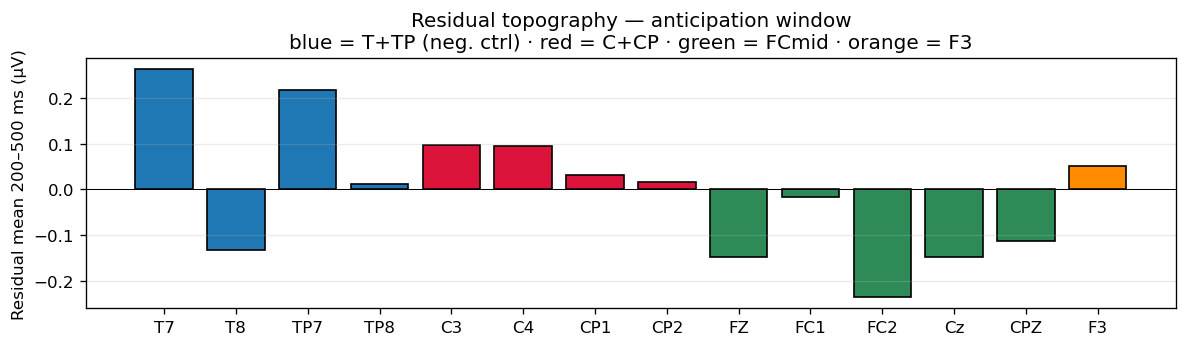

Per-subject ROI means in anticipation window:
  T+TP  : mean = +0.090 µV (n=14)
  C+CP  : mean = +0.060 µV (n=14)
  FCmid : mean = -0.132 µV (n=14)
  F3    : mean = +0.051 µV (n=14)

Paired t-tests (residual anticipation window):
  C+CP   − T+TP  : mean diff = -0.030 µV | p = 0.916
  FCmid  − T+TP  : mean diff = -0.222 µV | p = 0.505
  F3     − T+TP  : mean diff = -0.040 µV | p = 0.878
  FCmid  − C+CP  : mean diff = -0.192 µV | p = 0.103
  FCmid  − F3    : mean diff = -0.182 µV | p = 0.458

Reading: FCmid/C+CP/F3 should differ from T+TP; FCmid often shows the strongest CNV.


In [ ]:
ga_resid_ant = ga_resid[:, (times >= ANT_TMIN) & (times <= ANT_TMAX)].mean(axis=1)  # (n_ch,)

def _ch_color(ch):
    if ch in ROI_AUDITORY: return "#1f77b4"
    if ch in ROI_CENTRAL:  return "crimson"
    if ch in ROI_FC_MID:   return "seagreen"
    if ch in ROI_F3:       return "darkorange"
    return "gray"

fig, ax = plt.subplots(figsize=(10, 3))
colors = [_ch_color(ch) for ch in ch_names]
x = np.arange(len(ch_names))
ax.bar(x, ga_resid_ant, color=colors, edgecolor="k")
ax.axhline(0, color="k", lw=0.6)
ax.set_xticks(x)
ax.set_xticklabels(ch_names, rotation=0)
ax.set_ylabel("Residual mean 200–500 ms (µV)")
ax.set_title("Residual topography — anticipation window\nblue = T+TP (neg. ctrl) · red = C+CP · green = FCmid · orange = F3")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Per-subject ROI means + paired tests
per_sub = {"T+TP": [], "C+CP": [], "FCmid": [], "F3": []}
for sub_id in loaded:
    r = sub_pack[sub_id]["residual"].mean(axis=0)
    ant = r[:, (times >= ANT_TMIN) & (times <= ANT_TMAX)].mean(axis=1)
    for roi_name, roi_chs in [
        ("T+TP",  ROI_AUDITORY),
        ("C+CP",  ROI_CENTRAL),
        ("FCmid", ROI_FC_MID),
        ("F3",    ROI_F3),
    ]:
        ix = [ch_names.index(c) for c in roi_chs if c in ch_names]
        per_sub[roi_name].append(ant[ix].mean() if ix else np.nan)

per_sub = {k: np.array(v) for k, v in per_sub.items()}

print("Per-subject ROI means in anticipation window:")
for k, v in per_sub.items():
    print(f"  {k:6s}: mean = {np.nanmean(v):+.3f} µV (n={np.isfinite(v).sum()})")

print("\nPaired t-tests (residual anticipation window):")
for a_name, b_name in [
    ("C+CP",  "T+TP"),
    ("FCmid", "T+TP"),
    ("F3",    "T+TP"),
    ("FCmid", "C+CP"),
    ("FCmid", "F3"),
]:
    a, b = per_sub[a_name], per_sub[b_name]
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        continue
    t = stats.ttest_rel(a[m], b[m])
    print(f"  {a_name:6s} − {b_name:6s}: mean diff = {np.mean(a[m]-b[m]):+.3f} µV | p = {t.pvalue:.3g}")

print("\nReading: FCmid/C+CP/F3 should differ from T+TP; FCmid often shows the strongest CNV.")


## 10. Summary

| Step | Output |
|---|---|
| Subjects | exclude 1, 4, 14 |
| Cue condition | P1 (auditory cue → tactile target @ 500 ms) |
| Auditory-only control | BLA |
| Filter | `delta_beta` (1–30 Hz) |
| Baseline | −500…−50 ms |
| β fit window | 0–200 ms (auditory-dominated) |
| Anticipation window | 200–500 ms (on residual) |
| Anticipation ROIs | **FCmid** (FZ, FC1, FC2, Cz, CPZ — CNV core) + **C+CP** (C3, C4, CP1, CP2 — somato) + **F3** (left dlPFC, standalone) |
| Negative-control ROI | T+TP (T7, T8, TP7, TP8) |
| Time-domain features | residual mean 200–500 ms, residual CNV slope 200–500 ms |
| Frequency-domain features | α (8–13 Hz) / β (13–30 Hz) ERD (dB, Hilbert envelope) on raw P1 |
| Rolling window | 5 trials (centered) |
| Learning contrast | first-10 vs last-10 paired t + Wilcoxon |

**Three-layer answer to "how do you separate anticipation from auditory P3?"**
1. **Topographic:** features live on **FCmid** (CNV core) and **C+CP** (somato preparation); T+TP is an explicit negative control.
2. **Subtractive:** residual = P1 − β · BLA template with β fit on 0–200 ms — by construction the 200–500 ms residual is *not* the scaled auditory ERP.
3. **Frequency-orthogonal:** mu (8–13 Hz) / β (13–30 Hz) ERD on C+CP is in a different frequency regime than phase-locked auditory P3.

**ROI mapping to anticipation neuroscience:**
- **FCmid (FZ/FC1/FC2/Cz/CPZ)** — SMA / ACC generators of the CNV slow wave (Nagai 2004; Brunia & van Boxtel 2001)
- **F3 (left dlPFC)** — frontal attention / working-memory trace of cue–target association (Coull & Nobre 1998; Brunia 1999)
- **C+CP (C3/C4/CP1/CP2)** — contralateral S1 mu/β ERD (van Ede 2011; Haegens 2011); somato-SPN
- **T+TP (T7/T8/TP7/TP8)** — auditory cortex; after β · BLA removal, should be near zero in the anticipation window

**Next steps:**
- Correlate the residual CNV slope or α ERD slope across trials with behavioral measures if available.
- Repeat with P2 (variable ISI) and P3 (missing-tactile) to see whether anticipation scales with temporal or stimulus uncertainty.
- Optional: re-fit β over 0–300 ms and check whether the 300–500 ms residual direction is preserved (robustness check).
